# Measuring Program Impact of a Global Rollout without Clear Identification Strategy

This interactive notebook walks through a causal inference analysis for a leadership development program evaluation with **open enrollment** (voluntary participation).

---

## The Context

- Last year's employee engagement survey indicated a strong need for improved management skills. Additionally, leadership is concerned about consistently high manager turnover following recent organizational changes.
- To act on this, your organization's learning and development (L&D) team conducts leadership development trainings for people managers, aiming to better equip them to lead their teams through change and to decrease manager turnover.
- The L&D team will have a mid-year review of their projects with HR leadership and needs to be prepared with data to demonstrate impact and inform whether they should continue scaling the program or make changes to the program.

- The L&D team approaches you in **April** and tells you about their 3-month leadership development program that just concluded in **March**.
- They tried to train as many managers as possible this year. Consequently, participation was voluntary: **any manager** who signed up could attend Jan. - Mar training.
- You learn that promotion of the program varied across departments: some units actively encouraged participation, while others provided minimal outreach, limited to a single email announcement.
- You have access to 2 key measurement outcomes: 
    1. Manager responses to employee experience survey items (June)
    2. Manager rentention (exit date from Jan-Dec): date column plus binary survival flag at 3, 6, 9, 12 mon.
    Note: 9 and 12 month survival is technically outside the scenario scope (mid-year review), but we are keeping for illustrative purposes

### Timeline
```
          Jan─────Mar       Apr       Jun       Sep       Dec
          ╔═══════════╗
Trained   ║ TRAINING  ║
          ╚═══════════╝
                              ●         ●         ●         ●
                           3-mo     Survey     9-mo     12-mo
                            Ret.   + 6-mo      Ret.      Ret.
                                     Ret.
          ╔═══════════╗
Untrained ║  CONTROL  ║   (no training - observational comparison)
          ╚═══════════╝
```

---

## The Data & Outcomes

**Sample Sizes:**
- Cohort 1 (Trained) = 500 trained managers
- 'Control' pool = 8,500 untrained managers
**Available Variables:**
- Demographics/Org. Features: gender, age, tenure, region, team size (# direct reports), organization, job family, performance rating
- Manager Retention: exit date and binary flags indicating survival at 3/6/9/12 months

**Self-Report Experience Outcomes (1-5 scale):**

| Target | Outcome | Description |
|----------|----------|----------|
| Manager   | Manager Efficacy Index   | A self-assessment of manager confidence in their ability to lead and support their team through change. |
| Manager   | Workload Index    | A self-assessment a employee perceptions of workload, work-life balance, and well-being. |
| Manager | Turnover Intention Index | A self-assessment of employees' intention to stay at the company. (High score indicates high stay intention.) |


### Causal DAG (Directed Acyclic Graph)

Self-selection creates confounding: the same factors that drive participation also affect outcomes.

```mermaid
flowchart LR
    subgraph DAG2["Scenario 2: Open Enrollment"]
        direction LR
        
        X2["📋 <b>X</b><br/>Observed Covariates<br/>(Demographics,<br/>Dept, Performance)"]
        P["📢 <b>D</b><br/>Promotion<br/>Intensity"]
        U["❓ <b>U</b><br/>Unobserved<br/>(Motivation,<br/>Career Ambition)"]
        T2["💼 <b>T</b><br/>Treatment<br/>(Voluntary Enrollment)"]
        Y2["📈 <b>Y</b><br/>Outcomes<br/>(Retention, Survey Scores,<br/>Turnover Intent)"]
        
        X2 --> T2
        X2 --> Y2
        P --> T2
        P --> X2
        U --> T2
        U --> Y2
        T2 --> Y2
    end
    
    style X2 fill:#fff9c4,stroke:#f9a825,color:#000
    style P fill:#ffccbc,stroke:#d84315,color:#000
    style U fill:#ffcdd2,stroke:#d32f2f,color:#000,stroke-dasharray: 5 5
    style T2 fill:#ffe0b2,stroke:#ef6c00,color:#000
    style Y2 fill:#d1c4e9,stroke:#512da8,color:#000
```

**Key Causal Paths:**
- **X → T**: Observed confounding (demographics, dept, performance affect participation)
- **X → Y**: Same covariates predict outcomes
- **D → T, D → X**: Promotion intensity affects who participates
- **U → T, U → Y**: Unobserved confounding (motivated managers self-select AND perform better)
- **T → Y**: Causal effect of interest (but confounded without adjustment)

**Implications:**

| Path | Threat | Mitigation |
|------|--------|------------|
| X → T → Y | Observed confounding | IPTW or regression adjustment |
| U → T, U → Y | Unobserved confounding | Cannot fully address; sensitivity analysis |
| D → T | Selection by department | Include department in propensity model |

In [1]:
# =============================================================================
# SET-UP
# =============================================================================

import math
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import random
from scipy import stats
import seaborn as sns
import sys

sys.path.append(f'./supp_functions')
from causal_diagnostics import CausalDiagnostics #data-agnostic class for pre-modeling causal diagnostics (covariate overlap, positivity, etc.)
from causal_inference_modelling import CausalInferenceModel #causal inference class for IPTW-weighted GEE models (continuous and binary outcomes)

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

base_dir = Path.cwd()
data_dir = base_dir / "data"

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

c:\Users\U1008500\Documents\GitHub\2026-siop-causal-inference-master-tutorial\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#reload / import causal inference modeling class for IPTW-weighted GEE models (continuous and binary outcomes)
# import importlib
# import causal_diagnostics
# importlib.reload(causal_diagnostics)
# from causal_diagnostics import CausalDiagnostics

In [3]:
# =============================================================================
# LOAD & PREVIEW DATA
# =============================================================================

data = pd.read_csv(data_dir / "s2_manager_data.csv")
#drop propensity_score from data generation process if exists
if "propensity_score" in data.columns:
    data = data.drop(columns=["propensity_score"])

print("\n=== Shape ===")
print(f"data: {data.shape}")

print("\n=== Dtypes  ===")
print(data.dtypes)


print("\n=== Missing Values (Top 15) ===")
print(data.isna().sum().sort_values(ascending=False).head(15))

print("\n=== Head ===")
display(data.head())

treat_counts = data["treatment"].value_counts(dropna=False).sort_index()
print("\n=== Treatment Counts ===")
print(treat_counts)
if set(treat_counts.index) >= {0, 1}:
    ratio = treat_counts.loc[0] / max(treat_counts.loc[1], 1)
    print(f"Control:Treated ratio = {ratio:.1f}:1")



=== Shape ===
data: (9000, 24)

=== Dtypes  ===
id                                int64
team_id                           int64
treatment                         int64
region                           object
organization                     object
job_family                       object
performance_rating               object
gender                           object
age                               int64
tenure_months                     int64
is_new_manager                    int64
num_direct_reports                int64
tot_span_of_control               int64
baseline_manager_efficacy       float64
baseline_workload               float64
baseline_turnover_intention     float64
retention_3month                  int64
retention_6month                  int64
retention_9month                  int64
retention_12month                 int64
exit_date                        object
manager_efficacy_index          float64
workload_index_mgr              float64
turnover_intention_index_mgr   

,id,team_id,treatment,region,organization,job_family,performance_rating,gender,age,tenure_months,is_new_manager,num_direct_reports,tot_span_of_control,baseline_manager_efficacy,baseline_workload,baseline_turnover_intention,retention_3month,retention_6month,retention_9month,retention_12month,exit_date,manager_efficacy_index,workload_index_mgr,turnover_intention_index_mgr
0,1,448,0,Latin America,Manufacturing,Market Access,Meets,Male,38,9,0,7,14,1.7,4.0,3.2,1,1,1,1,NaN,2.1,5.0,2.5
1,2,199,0,Middle East & Africa,Commercial,Regulatory Affairs,Exceeds,Male,43,5,1,10,15,0.0,2.1,4.0,1,1,1,1,NaN,3.5,2.7,4.3
2,3,368,0,Asia Pacific,Manufacturing,Market Access,Exceeds,Male,38,7,0,8,28,2.3,2.9,2.8,0,0,0,0,2026-01-11,3.2,4.8,3.2
3,4,214,0,Middle East & Africa,Commercial,Pharmacovigilance,Exceeds,Male,28,16,0,9,11,4.6,1.0,3.4,1,1,1,1,NaN,4.7,1.7,3.5
4,5,812,0,Middle East & Africa,HR,IT & Digital,Meets,Male,45,10,0,5,14,3.1,3.1,2.5,1,1,1,1,NaN,2.8,3.6,2.2



=== Treatment Counts ===
treatment
0    8513
1     487
Name: count, dtype: int64
Control:Treated ratio = 17.5:1


In [4]:
# =============================================================================
# DATA HYGIENE CHECK
# =============================================================================

#summary stats
print("\n=== Data Summary Stats ===")
display(data.describe(include="all").T)

#check n missing by column
print("\n=== Missing Values by Column ===")
missing_counts = data.isna().sum()
missing_counts = missing_counts.sort_values(ascending=False)
print(missing_counts)



=== Data Summary Stats ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,9000.0,NaN,NaN,NaN,4500.5,2598.220545,1.0,2250.75,4500.5,6750.25,9000.0
team_id,9000.0,NaN,NaN,NaN,528.297444,307.555346,1.0,262.75,528.0,794.25,1063.0
treatment,9000.0,NaN,NaN,NaN,0.054111,0.226249,0.0,0.0,0.0,0.0,1.0
region,9000,5,Europe,1833,NaN,NaN,NaN,NaN,NaN,NaN,NaN
organization,9000,6,HR,1547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_family,9000,15,Regulatory Affairs,639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
performance_rating,9000,5,Meets,5407,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,9000,3,Female,4340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,9000.0,NaN,NaN,NaN,38.094111,5.710496,28.0,34.0,38.0,42.0,55.0
tenure_months,9000.0,NaN,NaN,NaN,12.000222,6.859276,1.0,7.0,11.0,16.0,36.0



=== Missing Values by Column ===
exit_date                       7241
id                                 0
team_id                            0
workload_index_mgr                 0
manager_efficacy_index             0
retention_12month                  0
retention_9month                   0
retention_6month                   0
retention_3month                   0
baseline_turnover_intention        0
baseline_workload                  0
baseline_manager_efficacy          0
tot_span_of_control                0
num_direct_reports                 0
is_new_manager                     0
tenure_months                      0
age                                0
gender                             0
performance_rating                 0
job_family                         0
organization                       0
region                             0
treatment                          0
turnover_intention_index_mgr       0
dtype: int64


DEMOGRAPHIC COMPARISON: Treated vs Control


,Control,Treated,Diff (T - C)
age,38.097,38.035,-0.063
tenure_months,12.016,11.723,-0.293
is_new_manager,0.245,0.287,0.043



------------------------------------------------------------


,Control %,Treated %,Diff (pp)
gender,,,
Female,48.2,48.7,0.5
Male,48.0,46.6,-1.3
Non-Binary/Other,3.9,4.7,0.9


,Control %,Treated %,Diff (pp)
region,,,
Asia Pacific,19.4,18.3,-1.1
Europe,20.1,24.6,4.5
Latin America,20.1,18.3,-1.8
Middle East & Africa,20.3,17.7,-2.7
North America,20.1,21.1,1.1


,Control %,Treated %,Diff (pp)
organization,,,
Commercial,17.0,11.7,-5.3
Digital,16.4,24.0,7.6
Finance,16.8,11.7,-5.1
HR,17.3,15.4,-1.9
Manufacturing,16.2,12.1,-4.1
R&D,16.2,25.1,8.8


,Control %,Treated %,Diff (pp)
job_family,,,
Clinical Operations,6.9,6.6,-0.3
Communications,6.7,6.2,-0.5
Data Science,6.8,4.9,-1.9
Finance & Accounting,6.4,7.4,1.0
Human Resources,6.3,7.0,0.7
IT & Digital,6.6,6.8,0.2
Legal & Compliance,6.4,7.6,1.1
Market Access,7.0,7.2,0.2
Marketing,6.8,7.6,0.8


,Control %,Treated %,Diff (pp)
performance_rating,,,
Below,15.7,0.0,-15.7
Exceeds,14.5,24.6,10.1
Far Below,5.2,0.0,-5.2
Far Exceeds,4.3,18.1,13.8
Meets,60.2,57.3,-2.9


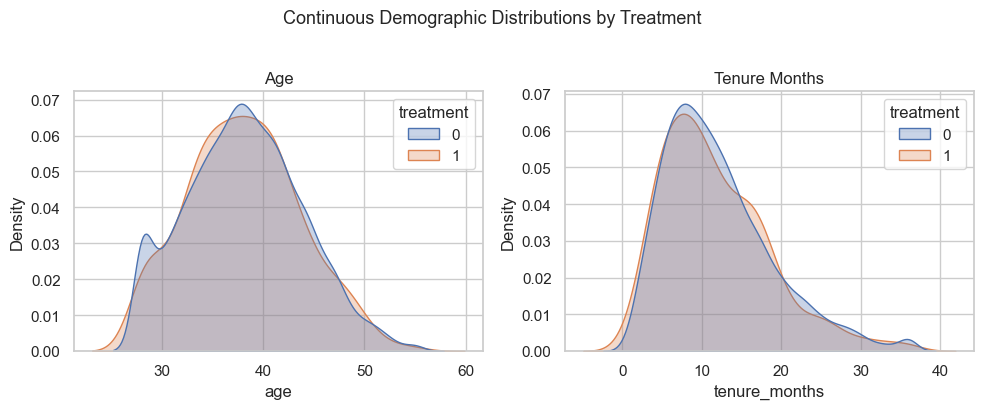

C:\Users\U1008500\AppData\Local\Temp\ipykernel_6084\1353114612.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


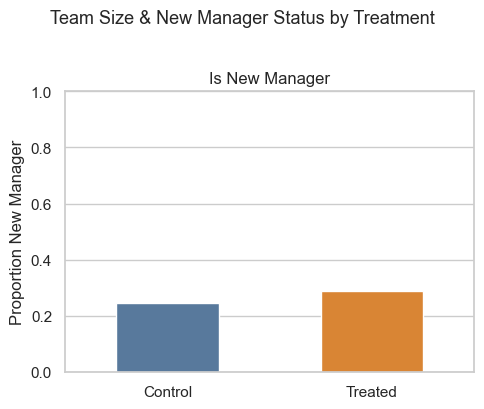

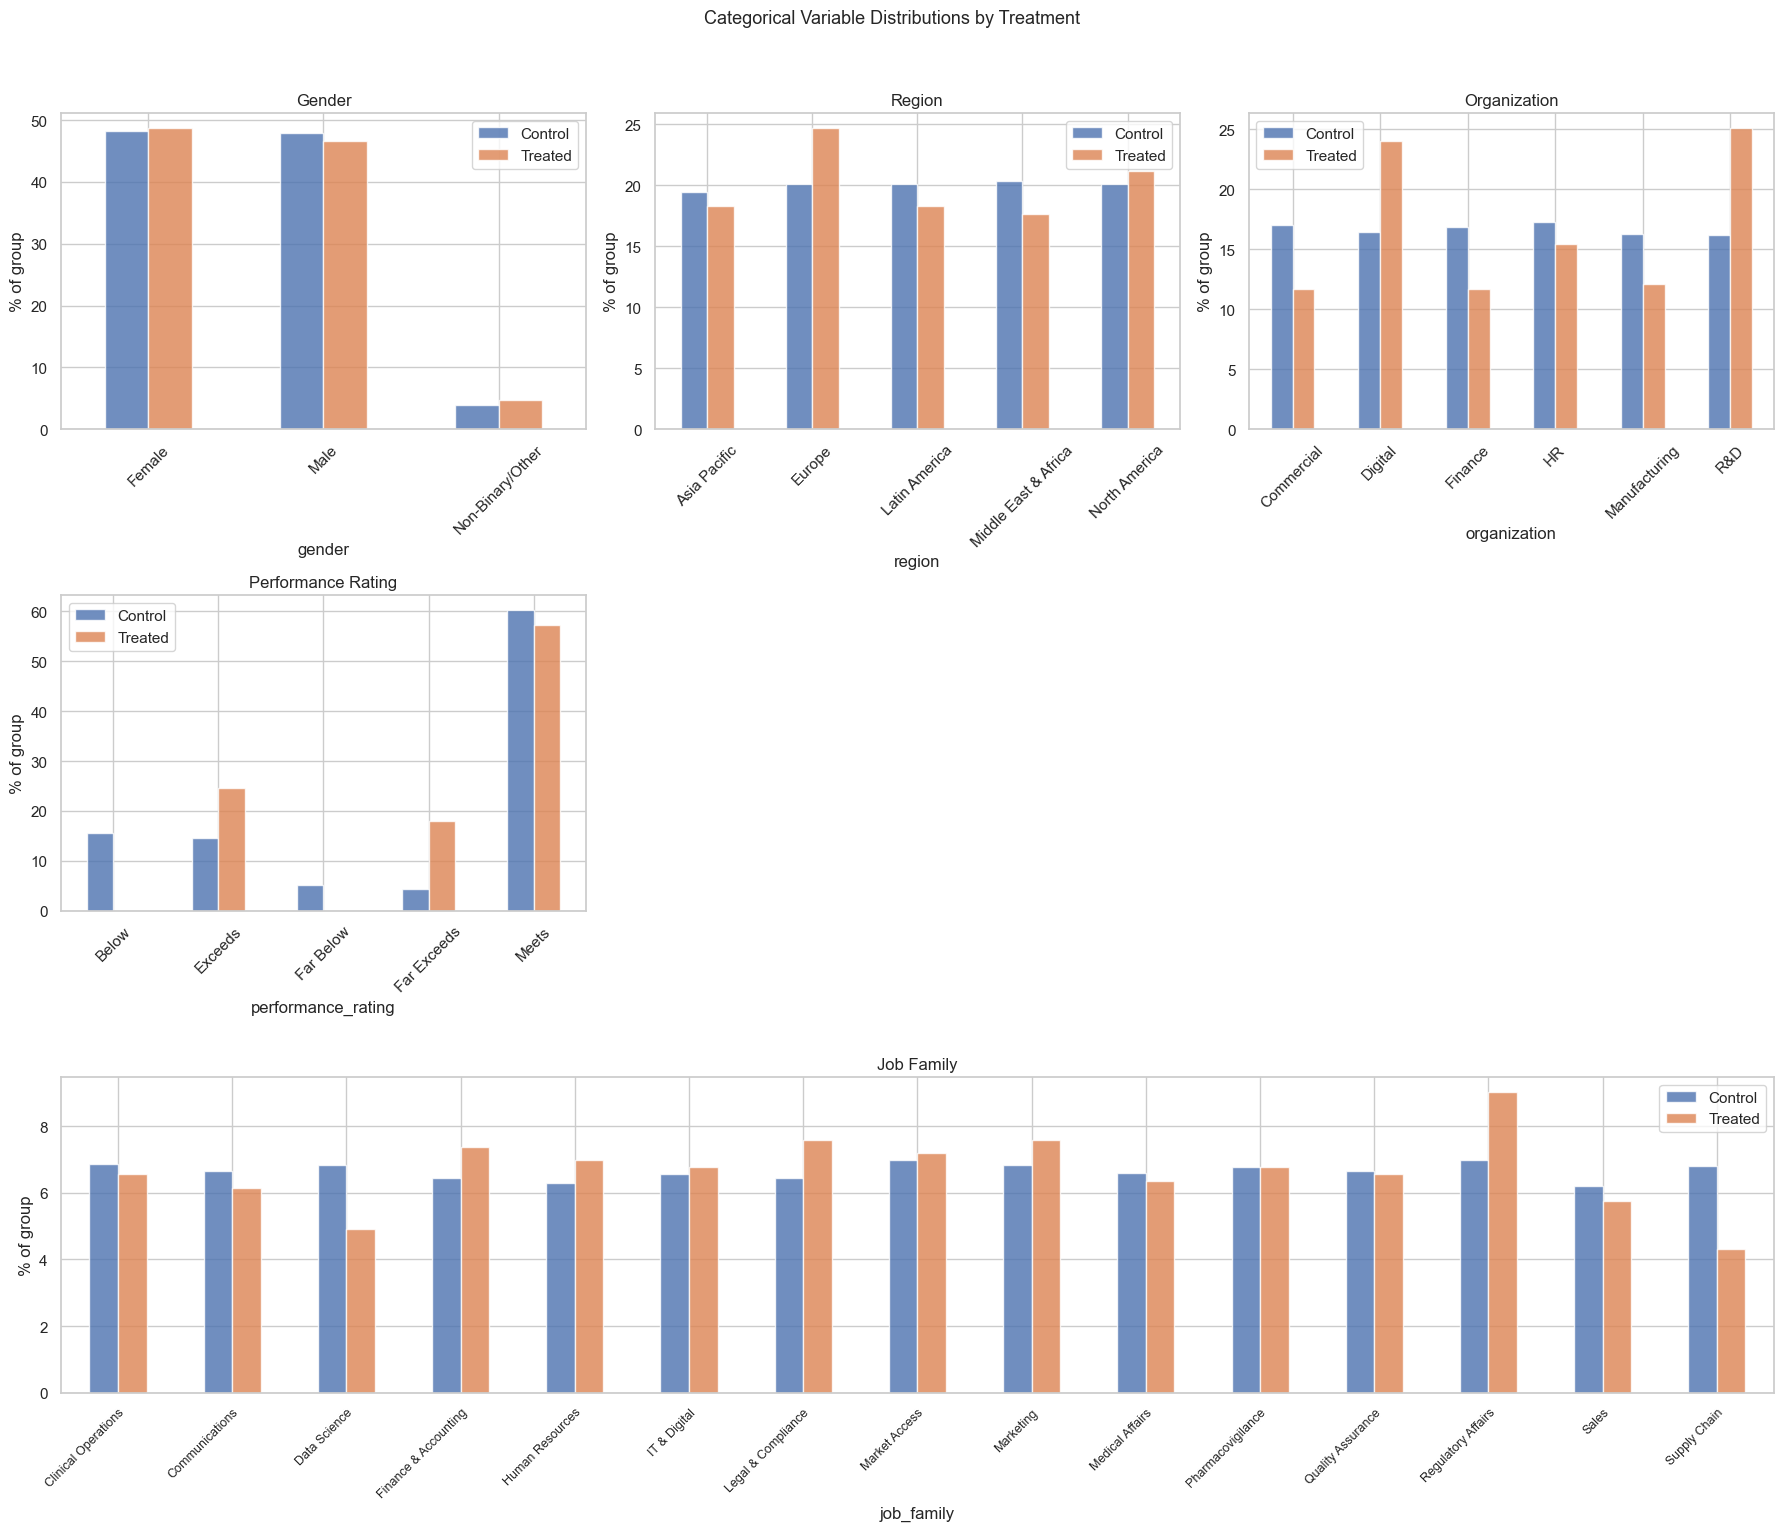

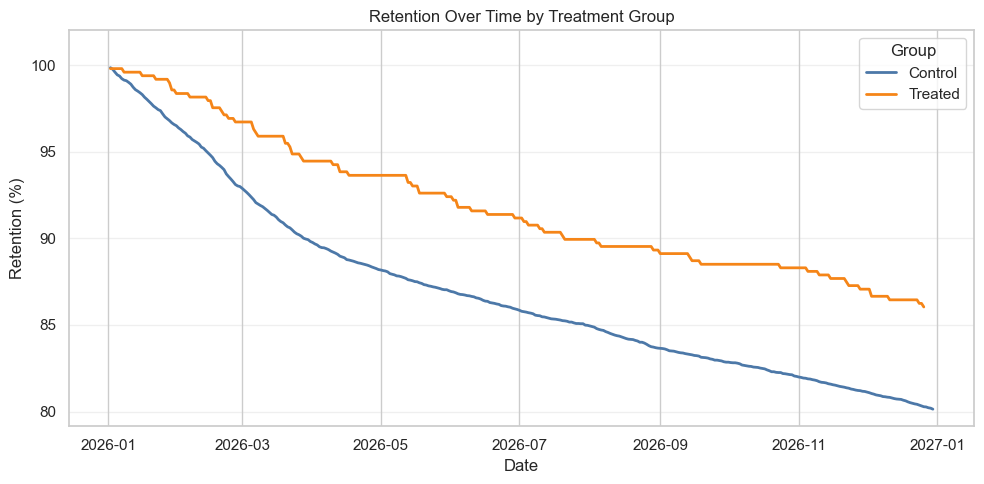

In [5]:
# =============================================================================
# DESCRIPTIVE EXPLORATION
# =============================================================================
# Compare outcomes for treated vs control, and explore potential confounders

# --- 1. Outcome columns ---
continuous_outcomes = [
    c for c in ["manager_efficacy_index", "workload_index_mgr", "turnover_intention_index_mgr"]
    if c in data.columns
]
binary_outcomes = [
    c for c in ["retention_3month", "retention_6month", "retention_9month", "retention_12month"]
    if c in data.columns
]
baseline_cols = [
    c for c in ["baseline_manager_efficacy", "baseline_workload",
                "baseline_turnover_intention", "baseline_manager_support"]
    if c in data.columns
]

# --- 2. Demographic / covariate comparison ---
demo_continuous = [c for c in ["age", "tenure_months"] if c in data.columns]
demo_num = demo_continuous + [c for c in ["team_size", "is_new_manager"] if c in data.columns]
demo_cat = [c for c in ["gender", "region", "organization", "job_family", "performance_rating"] if c in data.columns]

print("=" * 60)
print("DEMOGRAPHIC COMPARISON: Treated vs Control")
print("=" * 60)

# Continuous demographics: means
if demo_num:
    demo_means = data.groupby("treatment")[demo_num].mean().T
    demo_means.columns = ["Control", "Treated"]
    demo_means["Diff (T - C)"] = demo_means["Treated"] - demo_means["Control"]
    display(demo_means.round(3))

# Categorical demographics: proportions
if demo_cat:
    print("\n" + "-" * 60)
    for col in demo_cat:
        ct = pd.crosstab(data[col], data["treatment"])
        ct.columns = ["Control", "Treated"]

        # Proportions within each group
        ct_pct = ct.div(ct.sum(axis=0), axis=1) * 100
        ct_pct.columns = ["Control %", "Treated %"]
        ct_pct["Diff (pp)"] = ct_pct["Treated %"] - ct_pct["Control %"]

        display(ct_pct.round(1))

# Visualise demographic distributions
# Row 1: KDE for truly continuous vars (age, tenure)
n_cont = len(demo_continuous)
if n_cont:
    fig, axes = plt.subplots(1, n_cont, figsize=(5 * n_cont, 4))
    if n_cont == 1:
        axes = [axes]
    for ax, col in zip(axes, demo_continuous):
        sns.kdeplot(
            data=data, x=col, hue="treatment",
            common_norm=False, fill=True, alpha=0.3, ax=ax,
        )
        ax.set_title(col.replace("_", " ").title())
    plt.suptitle("Continuous Demographic Distributions by Treatment", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

# Row 2: Box plot for team_size, bar plot for is_new_manager
special_plots = []
if "team_size" in data.columns:
    special_plots.append("team_size")
if "is_new_manager" in data.columns:
    special_plots.append("is_new_manager")

if special_plots:
    fig, axes = plt.subplots(1, len(special_plots), figsize=(5 * len(special_plots), 4))
    if len(special_plots) == 1:
        axes = [axes]
    plot_df_special = data.copy()
    plot_df_special["treatment_label"] = plot_df_special["treatment"].map({0: "Control", 1: "Treated"})
    for ax, col in zip(axes, special_plots):
        if col == "team_size":
            sns.boxplot(
                data=plot_df_special, x="treatment_label", y=col, ax=ax,
                order=["Control", "Treated"],
                palette={"Control": "#4C78A8", "Treated": "#F58518"}, width=0.5,
            )
            ax.set_xlabel("")
            ax.set_title("Team Size")
        elif col == "is_new_manager":
            pct = (
                data.groupby("treatment")[col]
                .mean()
                .reset_index()
                .replace({"treatment": {0: "Control", 1: "Treated"}})
            )
            sns.barplot(
                data=pct, x="treatment", y=col, ax=ax,
                palette=["#4C78A8", "#F58518"], width=0.5,
            )
            ax.set_ylabel("Proportion New Manager")
            ax.set_xlabel("")
            ax.set_title("Is New Manager")
            ax.set_ylim(0, 1)
    plt.suptitle("Team Size & New Manager Status by Treatment", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

# Stacked bar charts for categorical variables
n_cat = len(demo_cat)
if n_cat:
    # Separate job_family from the rest
    other_cats = [col for col in demo_cat if col != "job_family"]
    n_other = len(other_cats)
    
    n_cols = 3
    n_rows = math.ceil(min(n_other, 6) / n_cols)
    
    # Create figure with GridSpec: regular rows + 1 wide row for job_family
    fig = plt.figure(figsize=(18, 5 * (n_rows + 1)))
    gs = GridSpec(n_rows + 1, n_cols, height_ratios=[1] * n_rows + [1])
    
    # Plot other categorical variables in the top rows
    for i, col in enumerate(other_cats[:n_rows * n_cols]):
        ax = fig.add_subplot(gs[i // n_cols, i % n_cols])
        ct_pct = pd.crosstab(data[col], data["treatment"], normalize="columns") * 100
        ct_pct.columns = ["Control", "Treated"]
        ct_pct.plot(kind="bar", ax=ax, alpha=0.8)
        ax.set_title(col.replace("_", " ").title())
        ax.set_ylabel("% of group")
        ax.legend(title="")
        ax.tick_params(axis="x", rotation=45)
    
    # Plot job_family on its own full-width row at the bottom
    if "job_family" in demo_cat:
        ax_job = fig.add_subplot(gs[n_rows, :])  # span all columns
        ct_pct = pd.crosstab(data["job_family"], data["treatment"], normalize="columns") * 100
        ct_pct.columns = ["Control", "Treated"]
        ct_pct.plot(kind="bar", ax=ax_job, alpha=0.8)
        ax_job.set_title("Job Family")
        ax_job.set_ylabel("% of group")
        ax_job.legend(title="")
        ax_job.tick_params(axis="x", rotation=45, labelsize=9)
        ax_job.set_xticklabels(ax_job.get_xticklabels(), ha="right", rotation_mode="anchor")
    
    plt.suptitle("Categorical Variable Distributions by Treatment", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

# --- 3. Retention over time by treatment group ---
if "exit_date" in data.columns:
    _exit_dates = pd.to_datetime(data["exit_date"], errors="coerce")
    _study_start = _exit_dates.min().normalize() if _exit_dates.notna().any() else pd.Timestamp("2025-01-01")
    # Build daily cumulative departure counts per treatment group
    _retention_lines = []
    for _trt, _label, _color in [(0, "Control", "#4C78A8"), (1, "Treated", "#F58518")]:
        _mask = data["treatment"] == _trt
        _n_group = _mask.sum()
        _dates = _exit_dates[_mask].dropna().sort_values()
        _daily_departures = _dates.dt.normalize().value_counts().sort_index().cumsum()
        # Build a complete daily index from first to last exit date
        _idx = pd.date_range(_daily_departures.index.min(), _daily_departures.index.max(), freq="D")
        _daily_departures = _daily_departures.reindex(_idx, method="ffill").fillna(0)
        _retention_pct = (1 - _daily_departures / _n_group) * 100
        _retention_lines.append((_label, _color, _retention_pct))

    fig, ax = plt.subplots(figsize=(10, 5))
    for _label, _color, _series in _retention_lines:
        ax.plot(_series.index, _series.values, label=_label, color=_color, linewidth=2)
    ax.set_xlabel("Date")
    ax.set_ylabel("Retention (%)")
    ax.set_title("Retention Over Time by Treatment Group")
    ax.legend(title="Group")
    ax.set_ylim(None, 102)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

### Exploration Key Takeaways:
1. Some imbalance between Treatment and Control for: Job Family, Organization, and Region. Control teams trends slightly larger.
2. Problematic imbalance for performance: no low performing managers signed up for training.


DEMOGRAPHIC COMPARISON: Treated vs Control


,Control,Treated,Diff (T - C)
age,38.143,38.035,-0.108
tenure_months,11.973,11.723,-0.250
is_new_manager,0.245,0.287,0.043



------------------------------------------------------------


,Control %,Treated %,Diff (pp)
gender,,,
Female,48.4,48.7,0.3
Male,47.8,46.6,-1.2
Non-Binary/Other,3.8,4.7,0.9


,Control %,Treated %,Diff (pp)
region,,,
Asia Pacific,19.5,18.3,-1.2
Europe,20.2,24.6,4.5
Latin America,19.9,18.3,-1.6
Middle East & Africa,20.2,17.7,-2.6
North America,20.2,21.1,0.9


,Control %,Treated %,Diff (pp)
organization,,,
Commercial,17.3,11.7,-5.6
Digital,16.1,24.0,7.9
Finance,16.7,11.7,-5.0
HR,17.4,15.4,-2.0
Manufacturing,16.6,12.1,-4.5
R&D,15.9,25.1,9.2


,Control %,Treated %,Diff (pp)
job_family,,,
Clinical Operations,6.7,6.6,-0.2
Communications,6.4,6.2,-0.2
Data Science,6.7,4.9,-1.7
Finance & Accounting,6.5,7.4,0.9
Human Resources,6.4,7.0,0.6
IT & Digital,6.6,6.8,0.2
Legal & Compliance,6.5,7.6,1.1
Market Access,7.1,7.2,0.1
Marketing,6.8,7.6,0.8


,Control %,Treated %,Diff (pp)
performance_rating,,,
Exceeds,18.4,24.6,6.3
Far Exceeds,5.5,18.1,12.6
Meets,76.2,57.3,-18.9


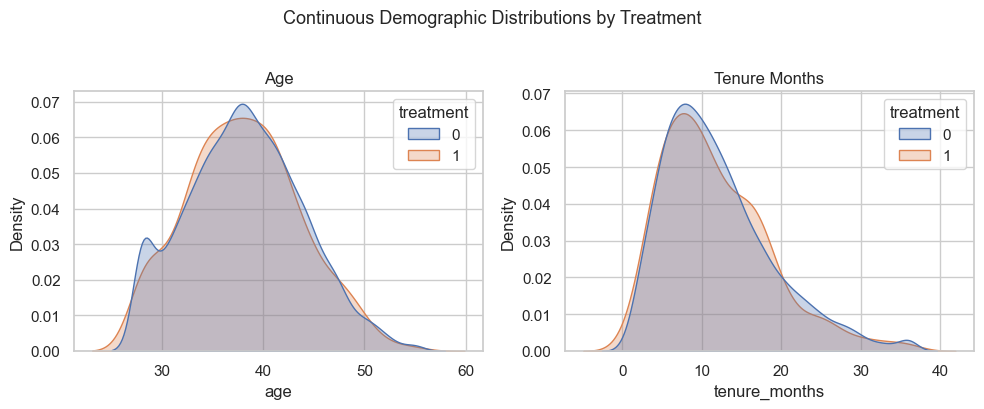

C:\Users\U1008500\AppData\Local\Temp\ipykernel_6084\476642567.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


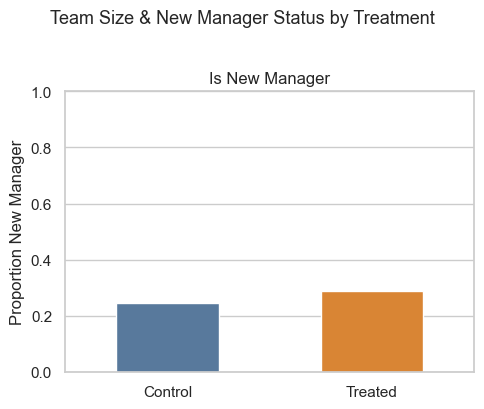

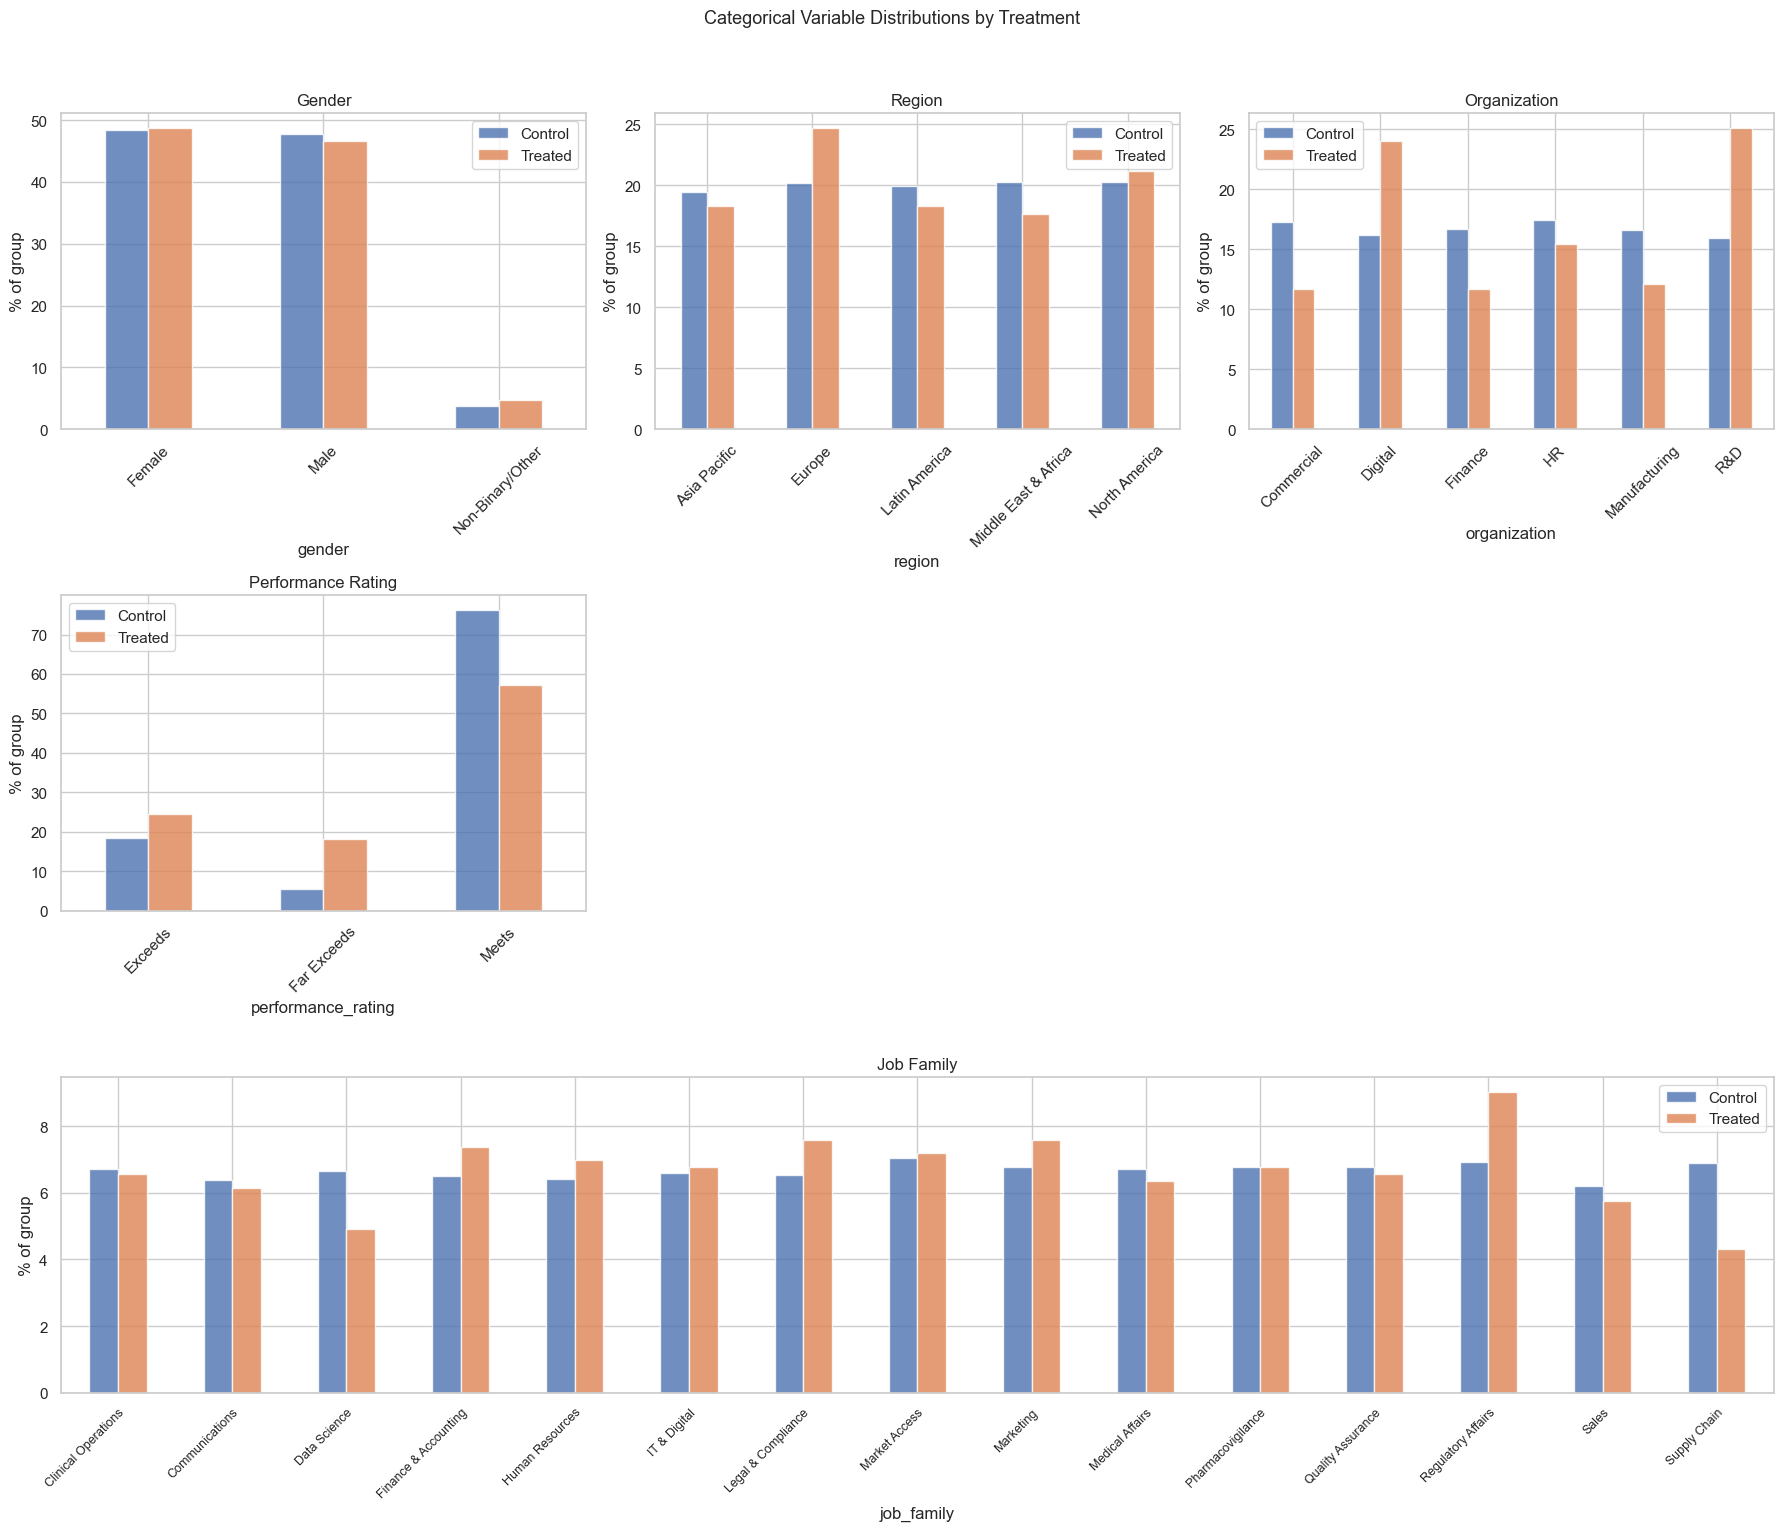

In [6]:
# Next Step:
# - Conduct statistical diagnostics for covariate overlap between treatment and control to get precise understanding of the severity of these imbalances.
# - Use diagnostics to determine appropriate method for estimating treatment effect.

#However, we know we will never achieve balance for performance rating because low performance did not participate. We have no way to extrapoluate effect for them.
#So, prior to running covariate balance, we will proactively exclude low performers. We will transparently report this decision and call out limitations in interpretation of the results.
#Ex. We cannot determine if this is an effective programe to intervene for low performers since they did not participate in the program. We can only determine if it is effective for mid/high performers. 

#remove performance_rating = Far Below or Below
data = data[~data["performance_rating"].isin(["Far Below", "Below"])].copy().reset_index(drop=True)
#rerun descriptives
# =============================================================================
# DESCRIPTIVE EXPLORATION
# =============================================================================
# Compare outcomes for treated vs control, and explore potential confounders

# --- 1. Outcome columns ---
continuous_outcomes = [
    c for c in ["manager_efficacy_index", "workload_index_mgr", "turnover_intention_index_mgr"]
    if c in data.columns
]
binary_outcomes = [
    c for c in ["retention_3month", "retention_6month", "retention_9month", "retention_12month"]
    if c in data.columns
]
baseline_cols = [
    c for c in ["baseline_manager_efficacy", "baseline_workload",
                "baseline_turnover_intention", "baseline_manager_support"]
    if c in data.columns
]

# --- 2. Demographic / covariate comparison ---
demo_continuous = [c for c in ["age", "tenure_months"] if c in data.columns]
demo_num = demo_continuous + [c for c in ["team_size", "is_new_manager"] if c in data.columns]
demo_cat = [c for c in ["gender", "region", "organization", "job_family", "performance_rating"] if c in data.columns]

print("=" * 60)
print("DEMOGRAPHIC COMPARISON: Treated vs Control")
print("=" * 60)

# Continuous demographics: means
if demo_num:
    demo_means = data.groupby("treatment")[demo_num].mean().T
    demo_means.columns = ["Control", "Treated"]
    demo_means["Diff (T - C)"] = demo_means["Treated"] - demo_means["Control"]
    display(demo_means.round(3))

# Categorical demographics: proportions
if demo_cat:
    print("\n" + "-" * 60)
    for col in demo_cat:
        ct = pd.crosstab(data[col], data["treatment"])
        ct.columns = ["Control", "Treated"]

        # Proportions within each group
        ct_pct = ct.div(ct.sum(axis=0), axis=1) * 100
        ct_pct.columns = ["Control %", "Treated %"]
        ct_pct["Diff (pp)"] = ct_pct["Treated %"] - ct_pct["Control %"]

        display(ct_pct.round(1))

# Visualise demographic distributions
# Row 1: KDE for truly continuous vars (age, tenure)
n_cont = len(demo_continuous)
if n_cont:
    fig, axes = plt.subplots(1, n_cont, figsize=(5 * n_cont, 4))
    if n_cont == 1:
        axes = [axes]
    for ax, col in zip(axes, demo_continuous):
        sns.kdeplot(
            data=data, x=col, hue="treatment",
            common_norm=False, fill=True, alpha=0.3, ax=ax,
        )
        ax.set_title(col.replace("_", " ").title())
    plt.suptitle("Continuous Demographic Distributions by Treatment", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

# Row 2: Box plot for team_size, bar plot for is_new_manager
special_plots = []
if "team_size" in data.columns:
    special_plots.append("team_size")
if "is_new_manager" in data.columns:
    special_plots.append("is_new_manager")

if special_plots:
    fig, axes = plt.subplots(1, len(special_plots), figsize=(5 * len(special_plots), 4))
    if len(special_plots) == 1:
        axes = [axes]
    plot_df_special = data.copy()
    plot_df_special["treatment_label"] = plot_df_special["treatment"].map({0: "Control", 1: "Treated"})
    for ax, col in zip(axes, special_plots):
        if col == "team_size":
            sns.boxplot(
                data=plot_df_special, x="treatment_label", y=col, ax=ax,
                order=["Control", "Treated"],
                palette={"Control": "#4C78A8", "Treated": "#F58518"}, width=0.5,
            )
            ax.set_xlabel("")
            ax.set_title("Team Size")
        elif col == "is_new_manager":
            pct = (
                data.groupby("treatment")[col]
                .mean()
                .reset_index()
                .replace({"treatment": {0: "Control", 1: "Treated"}})
            )
            sns.barplot(
                data=pct, x="treatment", y=col, ax=ax,
                palette=["#4C78A8", "#F58518"], width=0.5,
            )
            ax.set_ylabel("Proportion New Manager")
            ax.set_xlabel("")
            ax.set_title("Is New Manager")
            ax.set_ylim(0, 1)
    plt.suptitle("Team Size & New Manager Status by Treatment", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

# Stacked bar charts for categorical variables
n_cat = len(demo_cat)
if n_cat:
    # Separate job_family from the rest
    other_cats = [col for col in demo_cat if col != "job_family"]
    n_other = len(other_cats)
    
    n_cols = 3
    n_rows = math.ceil(min(n_other, 6) / n_cols)
    
    # Create figure with GridSpec: regular rows + 1 wide row for job_family
    fig = plt.figure(figsize=(18, 5 * (n_rows + 1)))
    gs = GridSpec(n_rows + 1, n_cols, height_ratios=[1] * n_rows + [1])
    
    # Plot other categorical variables in the top rows
    for i, col in enumerate(other_cats[:n_rows * n_cols]):
        ax = fig.add_subplot(gs[i // n_cols, i % n_cols])
        ct_pct = pd.crosstab(data[col], data["treatment"], normalize="columns") * 100
        ct_pct.columns = ["Control", "Treated"]
        ct_pct.plot(kind="bar", ax=ax, alpha=0.8)
        ax.set_title(col.replace("_", " ").title())
        ax.set_ylabel("% of group")
        ax.legend(title="")
        ax.tick_params(axis="x", rotation=45)
    
    # Plot job_family on its own full-width row at the bottom
    if "job_family" in demo_cat:
        ax_job = fig.add_subplot(gs[n_rows, :])  # span all columns
        ct_pct = pd.crosstab(data["job_family"], data["treatment"], normalize="columns") * 100
        ct_pct.columns = ["Control", "Treated"]
        ct_pct.plot(kind="bar", ax=ax_job, alpha=0.8)
        ax_job.set_title("Job Family")
        ax_job.set_ylabel("% of group")
        ax_job.legend(title="")
        ax_job.tick_params(axis="x", rotation=45, labelsize=9)
        ax_job.set_xticklabels(ax_job.get_xticklabels(), ha="right", rotation_mode="anchor")
    
    plt.suptitle("Categorical Variable Distributions by Treatment", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

---

## Causal Identification Strategy

- Participation was **voluntary** — any manager who signed up could attend the January–March training
- **Promotion varied across departments**: some units actively encouraged participation, others sent a single email announcement
- The L&D team's goal is to **train as many managers as possible** — they want to know if they should scale this program

**Our target estimand of interest: ATE (Average Treatment Effect)**

Since L&D wants to scale training to all managers, we need to estimate the **population-level effect** — what would happen if we assigned training to everyone vs. no one? This maps to the ATE, not the ATT (which only tells us about self-selected participants).

We will do some covariate overlap diagnostics to determine if our data structure is suitable to estimate ATE. If not, we can still get interesting insights from ATT. And, as a last resort, if the data set is not suitable for any causal inference, we would be limited to descriptive/exploratory analysis.

---

### Decision Flow

```mermaid
flowchart TB
    START2((("Scenario 2:<br/>Open Enrollment")))
    
    START2 --> S2
    S2["🎯 <b>Context</b><br/>500 managers self-selected<br/>vs 8,500 non-participants<br/>Target: ATE (population effect)"]
    
    S2 -->|"Step 1: Assignment"| A2
    A2["⚠️ <b>SELF-SELECTION</b><br/>Voluntary participation<br/>Uneven departmental promotion"]
    
    A2 -->|"Step 2: Covariate Overlap"| COV2
    COV2{"🔍 <b>EVALUATE OVERLAP</b><br/>Check balance on:<br/>Demographics, Dept, Performance"}
    
    COV2 -->|"Propensity scores<br/>well-distributed"| MOD["Moderate<br/>Imbalance"]
    COV2 -->|"Extreme scores,<br/>sparse overlap"| SEV["Severe<br/>Imbalance"]
    COV2 -->|"Perfect separation<br/>No overlap possible"| NOCI["No Causal<br/>Inference"]
    
    MOD -->|"Step 3: Estimand"| EST2A
    EST2A["📊 <b>ATE</b><br/>Population-level effect<br/>Reweight to target population"]
    
    SEV -->|"Step 3: Estimand"| EST2B
    EST2B["📊 <b>ATT</b><br/>Effect on the treated only<br/>Safer when overlap is poor"]
    
    NOCI --> DESC
    DESC["📋 <b>Descriptive Only</b><br/>Report observed differences<br/>No causal claims"]

    style START2 fill:#f57c00,stroke:#e65100,color:#fff
    style S2 fill:#ffe0b2,stroke:#ef6c00,color:#000
    style A2 fill:#ffccbc,stroke:#d84315,color:#000
    style COV2 fill:#fff9c4,stroke:#f9a825,color:#000
    style MOD fill:#dcedc8,stroke:#689f38,color:#000
    style SEV fill:#ffcdd2,stroke:#d32f2f,color:#000
    style NOCI fill:#ffcdd2,stroke:#d32f2f,color:#000
    style EST2A fill:#d1c4e9,stroke:#512da8,color:#000
    style EST2B fill:#d1c4e9,stroke:#512da8,color:#000
    style DESC fill:#f5f5f5,stroke:#9e9e9e,color:#000
```

| Step | Question | Answer  |
|------|----------|----------------------|
| 1 | How was treatment assigned? | ⚠️ **Self-selection** (voluntary participation) |
| 2 | Is there covariate overlap? | 🔍 **Must diagnose** (check propensity scores, SMDs) |
| 3 | What estimand is feasible? | 📊 **ATE** (moderate) or **ATT** (severe) or **Descriptive** (no overlap) |


In [7]:
###############################################
# SURVEY ANALYSIS — VARIABLE DEFINITIONS
###############################################

# Treatment variable
treatment = 'treatment'

# Survey outcome variables (continuous, with baselines)
survey_outcomes = [
    'manager_efficacy_index',
    'workload_index_mgr',
    'turnover_intention_index_mgr',
]

# Baseline variables corresponding to each survey outcome
baseline_vars = {
    'manager_efficacy_index': 'baseline_manager_efficacy',
    'workload_index_mgr': 'baseline_workload',
    'turnover_intention_index_mgr': 'baseline_turnover_intention',
}

# Covariates (shared between survey and retention analyses)
categorical_vars = [
    'gender',
    'organization',
    'job_family',
    'performance_rating',
    'region'
]

binary_vars = [
    'is_new_manager'
]

continuous_vars = [
    'age',
    'tenure_months',
    'num_direct_reports',
    'tot_span_of_control'
]

print(f"Survey outcomes:    {survey_outcomes}")
print(f"Covariates:         {len(categorical_vars)} categorical, {len(binary_vars)} binary, {len(continuous_vars)} continuous")

Survey outcomes:    ['manager_efficacy_index', 'workload_index_mgr', 'turnover_intention_index_mgr']
Covariates:         5 categorical, 1 binary, 4 continuous


In [8]:
# Instantiate CausalDiagnostics and view help
cd = CausalDiagnostics()
cd.help()


        ╔══════════════════════════════════════════════════════════════════════════════╗
        ║  CausalDiagnostics — Unified Causal Inference Diagnostic Toolkit            ║
        ╚══════════════════════════════════════════════════════════════════════════════╝

        Usage:
            from supp_functions.causal_diagnostics import CausalDiagnostics
            cd = CausalDiagnostics()

        ────────────────────────────────────────────────────────────────────────────────
        GROUP A: PRE-MODELING DIAGNOSTICS
        ────────────────────────────────────────────────────────────────────────────────

        1. check_high_intercorrelations(df, numerical_threshold=0.7,
                                        categorical_threshold=0.7, verbose=False,
                                        exclude_vars=None)
        Detect highly correlated variable pairs using:
            • Pearson correlation     (numerical–numerical)
            • Cramér's V              (categorical–catego

In [9]:
# ===========================================================================================================================================
# PRE-MODELING DIAGNOSTICS 1: Multicollinearity
# 1. Intercorrelations: Linear relationship between two variables at a time
# 2. Variance Inflation Factor (VIF): How much a variable is explained by ALL other variables combined
# ==========================================================================================================================================

# Variables to exclude from pre-modeling checks (outcomes, IDs, treatment)
# Include retention columns so they don't contaminate covariate diagnostics
retention_cols = [c for c in data.columns if c.startswith('retention_')]
exclude_from_diagnostics = (
    ['id', 'team_id', 'treatment', 'exit_date']
    + survey_outcomes
    + retention_cols
    + [v for v in baseline_vars.values() if v is not None]
)

# --- Check 1: Intercorrelations ---
print("=" * 60)
print("CHECK 1: INTERCORRELATIONS")
print("=" * 60)
intercorr = cd.check_high_intercorrelations(
    data,
    numerical_threshold=0.7,
    categorical_threshold=0.7,
    verbose=True,
    exclude_vars=exclude_from_diagnostics,
)
if not intercorr['all_high_correlation_pairs']:
    print("✅ No highly correlated pairs found.")
else:
    print(f"⚠️ Found {len(intercorr['all_high_correlation_pairs'])} highly correlated pair(s).")

# --- Check 2: Variance Inflation Factor (VIF) ---
print("\n" + "=" * 60)
print("CHECK 2: VARIANCE INFLATION FACTOR (VIF)")
print("=" * 60)
controls_for_vif = categorical_vars + binary_vars + continuous_vars
vif_results = cd.check_vif(
    data,
    controls=controls_for_vif,
    treatment='treatment',
)
display(vif_results)

CHECK 1: INTERCORRELATIONS
✅ No highly correlated pairs found.

CHECK 2: VARIANCE INFLATION FACTOR (VIF)


,Variable,Type,VIF / GVIF,Adjusted (GVIF^1/2df),Shared Variance,Severity
0,num_direct_reports,Continuous,1.1151,1.1151,<25% of variance is shared,✅ None
1,tot_span_of_control,Continuous,1.1150,1.1150,<25% of variance is shared,✅ None
2,tenure_months,Continuous,1.0812,1.0812,<25% of variance is shared,✅ None
3,is_new_manager,Continuous,1.0798,1.0798,<25% of variance is shared,✅ None
4,treatment,Continuous,1.0332,1.0332,<25% of variance is shared,✅ None
5,performance_rating,Categorical (2 dummies),1.0299,1.0074,<25% of variance is shared,✅ None
6,age,Continuous,1.0054,1.0054,<25% of variance is shared,✅ None
7,organization,Categorical (5 dummies),1.0263,1.0026,<25% of variance is shared,✅ None
8,region,Categorical (4 dummies),1.0153,1.0019,<25% of variance is shared,✅ None
9,gender,Categorical (2 dummies),1.0074,1.0018,<25% of variance is shared,✅ None


### Key Takeaways from Initial Diagnostics
- No major multi-collinearity concerns.

Next Step:
- Proceed with covariate overlap diagnostics.

---

## Key Diagnostic Questions

Before choosing between ATT and ATE:

Consider the research question...
What question are we trying to answer?
- ATE answers: 
    - "What is the average causal effect of the treatment across the entire population, regardless of whether they actually received the treatment?"
    - "Should we roll this out to everyone?"
- ATT answers: 
    - "What is the average causal effect of the treatment specifically for those who actually received the treatment?"
    - "Did this work for those who got it?"

Given the L&D teams motivation to impact as many managers as possible, ATE would be a useful estimation. But first, we need to ensure our data can elicit a defensible ATE estimand. We can do this by running the following diagnostics:
1. **Propensity Score Distribution**: Are scores clustered at extremes (0 or 1)?
2. **Common Support**: What proportion of treated units have comparable controls?
3. **Standardized Mean Differences**: Are any SMDs > 0.25 after weighting?
4. **Effective Sample Size**: Does IPTW drastically reduce effective N?

```mermaid
flowchart LR
    subgraph DIAG["Diagnostic Decision Guide"]
        D1["Check PS<br/>Distribution"] --> D2{"Extreme<br/>clustering?"}
        D2 -->|"Yes"| D3["→ Use ATT"]
        D2 -->|"No"| D4["Check<br/>SMDs"]
        D4 --> D5{"SMDs > 0.25<br/>after weighting?"}
        D5 -->|"Yes"| D3
        D5 -->|"No"| D6["→ May Use ATE"]
    end
    
    style D1 fill:#e3f2fd,stroke:#1976d2,color:#000
    style D2 fill:#fff9c4,stroke:#f9a825,color:#000
    style D3 fill:#ffcdd2,stroke:#d32f2f,color:#000
    style D4 fill:#e3f2fd,stroke:#1976d2,color:#000
    style D5 fill:#fff9c4,stroke:#f9a825,color:#000
    style D6 fill:#c8e6c9,stroke:#388e3c,color:#000
```

In [10]:
# ===========================================================================================================================================
# PRE-MODELING DIAGNOSTICS : IS CAUSAL COMPARISON CREDIBLE, AND WHAT ESTIMAND IS DEFENSIBLE?
# 1. Overlap Diagnostics: Do the treatment and control groups have sufficient overlap in covariate distributions?
# 2. Based on the diagnostics, determine if the data supports a credible causal comparison.
# ===========================================================================================================================================
# Note: Overlap diagnostics are run on survey outcomes only. The propensity score model depends on
# covariates + treatment (not the outcome), so propensity score overlap is identical for the survival
# analysis. We run it here once for the 3 survey outcomes and will re-verify briefly for retention later.

overlap_results = cd.run_overlap_diagnostics(
    data=data,
    treatment_var=treatment,
    outcome_vars=survey_outcomes,
    baseline_vars=baseline_vars,
    categorical_vars=categorical_vars,
    binary_vars=binary_vars,
    continuous_vars=continuous_vars,
)


STEP 2: OVERLAP / COMMON SUPPORT DIAGNOSTICS

    This step determines WHICH ESTIMAND (ATT vs ATE) is credible in your data.

    KEY CONCEPTS:
    - ATT (Average Treatment Effect on the Treated): Effect for those who got treatment
    → Requires: Good overlap for TREATED units (each treated has comparable controls)

    - ATE (Average Treatment Effect): Effect if we treated everyone
    → Requires: Good overlap BOTH directions (treated exist across control range too)

    With imbalanced samples, ATT is typically the credible estimand because
    many controls sit in regions where no treated units exist.

    We'll check overlap for each outcome (since adjustment sets include different baselines).
        
DETAILED DIAGNOSTICS
Checks 1A–1C (continuous, binary, categorical SMDs) are identical
across outcomes. Only baseline check (1D) and propensity-score model
(Check 2) vary by outcome due to outcome-specific baseline variables.
Showing full detail for first outcome: manager_efficacy_

,Outcome,AUC,Treated Overlap %,Control Overlap %,Max |SMD| (Source),Baseline Balance,Imbalanced Vars,Estimand,Rationale
0,manager_efficacy_index,0.650,89.7,91.5,0.401 (performance_rating),✓ Good (0.082),performance_rating (0.40); organization (0.23)...,ATE,Strong bidirectional overlap; ATE fully defens...
1,workload_index_mgr,0.648,88.9,91.9,0.401 (performance_rating),✓ Good (0.002),performance_rating (0.40); organization (0.23)...,ATE,Strong bidirectional overlap; ATE fully defens...
2,turnover_intention_index_mgr,0.645,89.9,91.4,0.401 (performance_rating),✓ Good (0.041),performance_rating (0.40); organization (0.23)...,ATE,Strong bidirectional overlap; ATE fully defens...



INTERPRETATION GUIDE: WHAT THIS MEANS FOR YOUR ANALYSIS

    ╔══════════════════════════════════════════════════════════════════════════════╗
    ║  WHAT IS COVARIATE OVERLAP AND WHY DOES IT MATTER?                           ║
    ╠══════════════════════════════════════════════════════════════════════════════╣
    ║                                                                              ║
    ║  Causal inference requires COMPARABLE treatment and control groups.          ║
    ║  "Comparable" means: for each treated person, there exist control people     ║
    ║  with similar characteristics (covariates) who can serve as counterfactuals. ║
    ║                                                                              ║
    ║  If groups occupy DIFFERENT covariate spaces, we cannot observe what would   ║
    ║  have happened to treated people without treatment — we must EXTRAPOLATE.    ║
    ║                                                                              ║
    ║  

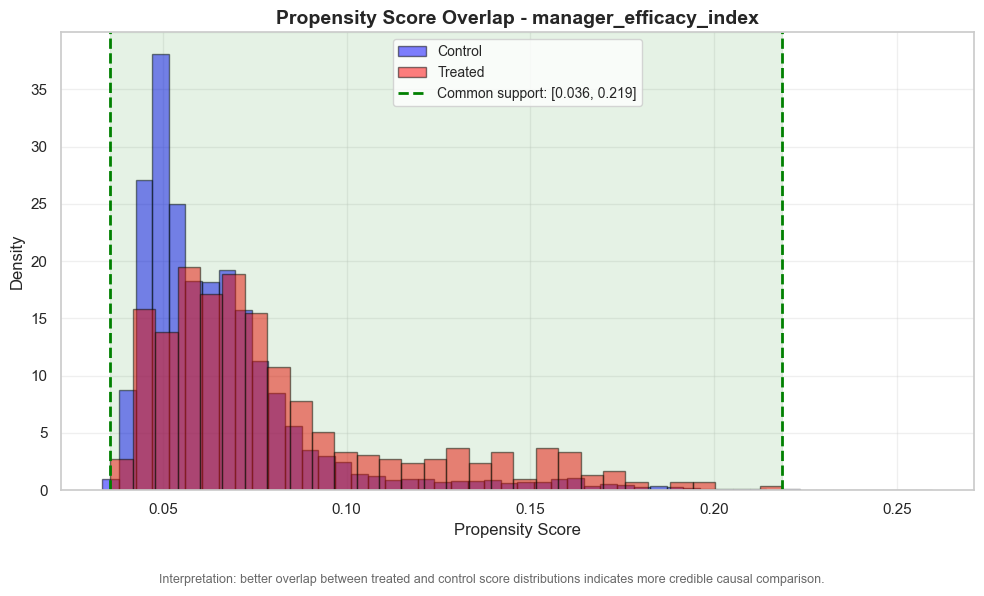

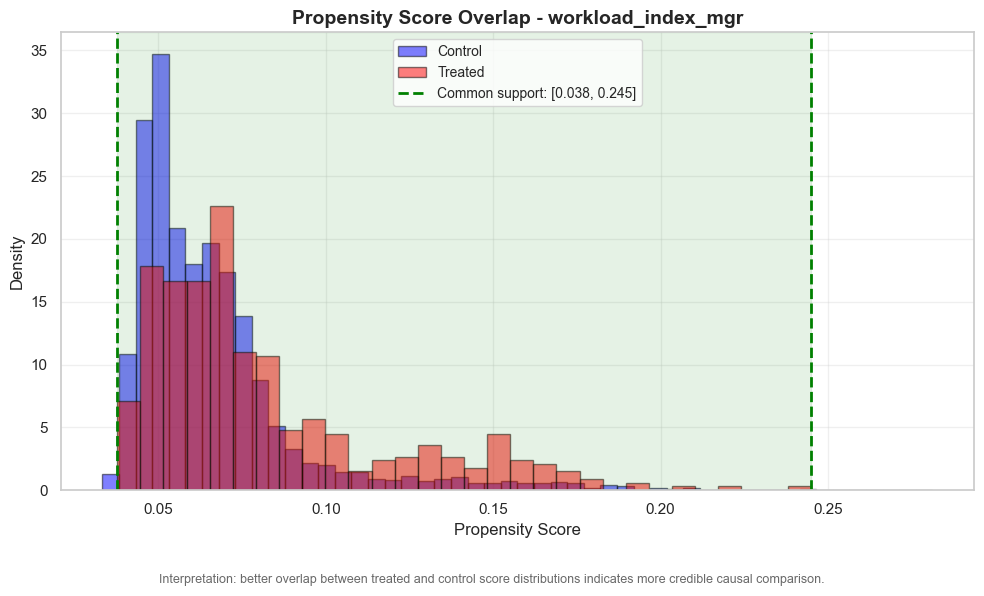

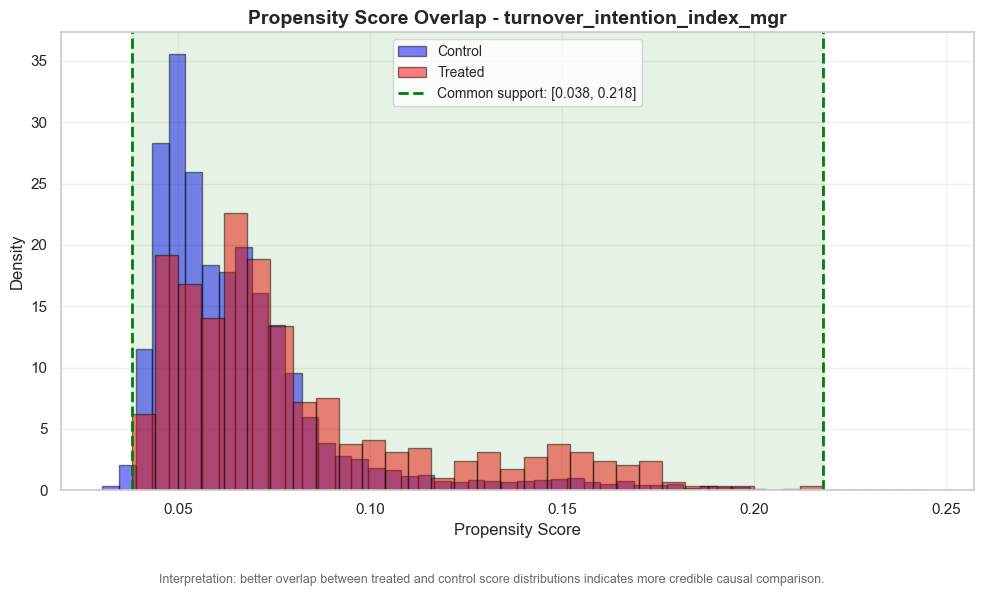

In [11]:
# =============================================================================
# Visualize propensity score overlap per survey outcome
# =============================================================================
for outcome_var in survey_outcomes:
    result = overlap_results.get(outcome_var)
    if result is None:
        continue

    ps = result.get('propensity_scores')
    if ps is not None:
        cd.plot_propensity_overlap(
            data=data,
            treatment_var=treatment,
            propensity_scores=ps,
            outcome_var=outcome_var,
        )

In [12]:
# =============================================================================
# Save overlap diagnostics summary
# =============================================================================
cd.save_overlap_diagnostics_summary(
    overlap_results,
    save_path=str(base_dir / "results/s2_overlap_diagnostics_summary.txt"),
)


✓ Diagnostics summary saved to: c:\Users\U1008500\Documents\GitHub\2026-siop-causal-inference-master-tutorial\results\s2_overlap_diagnostics_summary.txt


### Key Takeaways from Covariate Overlap Diagnostics
- After removing untreated controls (Low performers), all diagnostics suggest that we can reasonably estimate ATE.
- AUC is <0.7 and we see sufficient overlap of the treatment group in the control group, and vice versa (~90% for both overlap directions).
    - This indicates that treatment and control groups are similar to each other and treatment assignment is quasi-random. (Covariates cannot fully predict the outcome.)
- The data contains moderate imbalance across: region, remaining performance categories, organization, and job family. 
    - We will address this through Inverse Probability of Treatment Weighting (IPTW) with Generalized Estimating Equations (GEE)


Next Step:
- Proceed with ATE model specification and execution.

---

## Estimating Average Treatment Effect using IPTW + GEE (for Moderate Imbalance)

Use this approach when treatment is not purely randomized, propensity scores are well-distributed (good overlap), and weighted standardized mean differences (SMDs) are acceptable after weighting.

This approach estimates the **Average Treatment Effect (ATE)** using:

- Stabilized and trimmed inverse probability of treatment weights (IPTW)
- GEE to account for clustering (individuals nested within their direct manager's team)
- Robust (sandwich) standard errors
- Covariate adjustment in the outcome model for **doubly robust estimation**

> **Note on estimand:** GEE itself is agnostic to the estimand — it simply fits a weighted regression with cluster-robust standard errors. Whether you estimate the **ATE** or the **ATT** is determined entirely by how the weights are constructed. This implementation uses **ATE weights**, which reweight both treated and control groups to represent the full population.

---

Let:

- $Y_i$ = outcome for individual $i$
- $Treatment_i$ = 1 if individual $i$ participated, 0 otherwise
- $X_i$ = pre-treatment individual-level covariates
- $Team_i$ = the direct manager's team that individual $i$ belongs to (used for clustering)

The weighted GEE model is:

$$
g\big(E[Y_i]\big) =
\beta_0 + \beta_1 \cdot Treatment_i + \beta_2 \cdot X_i
$$

Where:

- $g(\cdot)$ is the link function (identity for continuous outcomes, logit for binary outcomes)
- Weights = **stabilized and trimmed ATE inverse probability weights**
- Propensity scores are estimated at the **individual level** — one score per person, reflecting the probability that an individual received treatment given their observed covariates: $\hat{e}_i = P(Treatment_i = 1 \mid X_i)$
- **ATE weights** are then constructed as:
  - Treated individuals: $w_i = 1 \;/\; \hat{e}_i$
  - Control individuals: $w_i = 1 \;/\; (1 - \hat{e}_i)$
  - This reweights **both** groups to represent the full population — upweighting individuals who were unlikely to receive the treatment they actually received
  - For comparison, **ATT weights** would leave treated individuals unweighted ($w_i = 1$) and reweight controls as $w_i = \hat{e}_i \;/\; (1 - \hat{e}_i)$ to match the treated group's covariate distribution. The choice of ATE vs. ATT is entirely determined by the weight formula, not by GEE.
- Weights are **stabilized** by multiplying by the marginal treatment probability:
  - Treated: $w_i^{stab} = \bar{p} \;/\; \hat{e}_i$
  - Control: $w_i^{stab} = (1 - \bar{p}) \;/\; (1 - \hat{e}_i)$
  - where $\bar{p}$ is the sample-average treatment probability. Stabilization reduces the range of weight values while preserving balance.
- Weights are **trimmed** by capping values above a specified quantile (e.g., 99th percentile). This reduces the influence of individuals with extreme propensity scores — those who were very unlikely to receive the treatment they actually received — which can otherwise destabilize estimates. Trimming introduces a small bias but substantially reduces variance.
- Clustering is specified at the **team level** (by direct manager ID) — individuals who share the same direct manager are grouped together. GEE sandwich standard errors account for the fact that teammates may have correlated outcomes due to shared work environment, leadership, and team dynamics.
- Note: GEE sandwich standard errors account for within-team correlation but do **not** propagate uncertainty from the first-stage propensity score estimation. For stricter inference, consider a non-parametric bootstrap that re-estimates both stages in each replicate.

---

### Continuous Outcome (Identity Link)

$$
E[Y_i] =
\beta_0 + \beta_1 \cdot Treatment_i + \beta_2 \cdot X_i
$$

- $\beta_1$ = **ATE**: the weighted average difference in outcomes between treated and control individuals, after reweighting to balance observed confounders
- Interpretation: on average across the population, treatment shifts the outcome by $\beta_1$ units

---

### Binary Outcome (Logit Link)

$$
\log\left(\frac{P(Y_i=1)}{1-P(Y_i=1)}\right)
=
\beta_0 + \beta_1 \cdot Treatment_i + \beta_2 \cdot X_i
$$

- $e^{\beta_1}$ = **population-averaged marginal odds ratio**: the odds of the outcome occurring for treated individuals relative to control individuals, averaged across the population
- Note: because GEE estimates population-averaged (marginal) effects rather than subject-specific effects, $e^{\beta_1}$ reflects the average odds ratio across all individuals, not the odds ratio for any particular person

---

## Doubly Robust Interpretation

The model is **doubly robust**: $\beta_1$ consistently estimates the ATE if **at least one** of the following holds:

- The propensity score model $P(Treatment_i = 1 \mid X_i)$ is correctly specified, **or**
- The outcome model (including $X_i$) is correctly specified

Both models being misspecified simultaneously will produce biased estimates. In practice, doubly robust estimation is most valuable as a safeguard — not a substitute for careful model specification in both stages.

Two additional assumptions are always required regardless of model correctness:

- **Positivity (overlap):** Every individual must have a non-zero probability of receiving either treatment or control given their covariates — i.e., $0 < P(Treatment_i = 1 \mid X_i) < 1$ for all $i$. Violations (propensity scores near 0 or 1) produce extreme weights and unstable estimates.
- **Correct temporal ordering:** All covariates $X_i$ must be measured **prior to** treatment assignment to qualify as true pre-treatment confounders. Including post-treatment variables as covariates can introduce bias.

---

## Summary: Model Design Choices

| Design Choice | Problem It Solves | Example | What It Does |
|---------------|-------------------|---------|--------------|
| **IPTW (Inverse Probability of Treatment Weighting)** | Treatment assignment is non-random; treated and control groups differ on observed confounders | Individuals who volunteered for training differ systematically from those who didn't (e.g., higher baseline performance, more tenure) | Reweights observations so treated and control groups have balanced covariate distributions, mimicking randomization. Upweights individuals who were unlikely to receive the treatment they got; downweights those who were likely to receive it. |
| **ATE Weights** | You want to estimate the effect of treatment across the **full population**, not just those who were treated | Deciding whether to mandate a program for all individuals | Reweights **both** treated and control groups to represent the full population. Treated: $w_i = 1/\hat{e}_i$, Control: $w_i = 1/(1-\hat{e}_i)$. Contrast with ATT weights, which leave treated unweighted and reweight controls to match the treated group. |
| **Stabilized Weights** | Extreme weights from rare propensity scores cause high variance and unstable estimates | An individual with PS = 0.02 gets weight = 1/0.02 = 50, dominating the analysis | Multiplies weights by the marginal treatment probability $\bar{p}$, reducing the range of weight values while preserving balance. Stabilized weights have mean ≈ 1 instead of highly variable. |
| **Weight Trimming** | A few individuals with extreme propensity scores (near 0 or 1) produce outlier weights that destabilize estimates | One person with PS = 0.001 gets weight = 1000, overwhelming all other observations | Caps weights at a specified quantile (e.g., 99th percentile). Introduces small bias but substantially reduces variance. Trades off some precision for stability. |
| **GEE Clustering** | Observations within groups (teams) are not independent; teammates share common shocks and environments | Individuals under the same manager have correlated outcomes due to shared leadership style, team culture, workload | Models within-cluster correlation structure and adjusts coefficient estimation accordingly. Produces population-averaged (marginal) effects rather than cluster-specific effects. Prevents underestimation of standard errors. |
| **Sandwich (Robust) Standard Errors** | Model assumptions about variance structure may be wrong (heteroskedasticity, misspecified correlation) | You assumed exchangeable correlation within teams, but the true correlation structure is more complex | Uses observed residuals to empirically estimate the true variance, producing standard errors that are valid even if variance assumptions are violated. Makes GEE robust to misspecification of the working correlation structure. |
| **Doubly Robust Estimation** | Uncertainty about whether propensity score model or outcome model is correctly specified | You're not sure if you've included all relevant confounders, or if the functional form of relationships is correct | Includes covariates in both the propensity score model (via weights) and the outcome model (via regression adjustment). ATE estimate is consistent if **either** model is correct — you get two chances instead of one. |
| **Propensity Score Clipping** | Division by propensity scores near 0 or 1 produces infinite or undefined weights | Propensity score = 0.0000001 → weight = 10,000,000 | Clips propensity scores to a safe range (e.g., [0.000001, 0.999999]) before calculating weights. Prevents numerical overflow and extreme weight values. |
| **Auto-Detection of Outcome Family** | Binary and continuous outcomes require different link functions and distributional assumptions | Retention (0/1) needs logit link; engagement score (1-5) needs identity link | Inspects unique values of the outcome variable. If only {0, 1}, uses Binomial family with logit link. Otherwise, uses Gaussian family with identity link. Ensures appropriate model specification. |
| **Multiple Testing Correction (FDR)** | Testing multiple outcomes inflates Type I error rate (false positives) | Testing 7 outcomes at α=0.05 gives ~30% chance of at least one false positive under the null | Applies Benjamini-Hochberg FDR correction across all p-values within an outcome family. Controls the expected proportion of false discoveries among rejected hypotheses. Applied **across outcomes**. |

In [13]:
#reload / import causal inference modeling class for IPTW-weighted GEE models (continuous and binary outcomes)
# import importlib
# import causal_inference_modelling
# importlib.reload(causal_inference_modelling)
# from causal_inference_modelling import CausalInferenceModel


ANALYZING OUTCOME: manager_efficacy_index


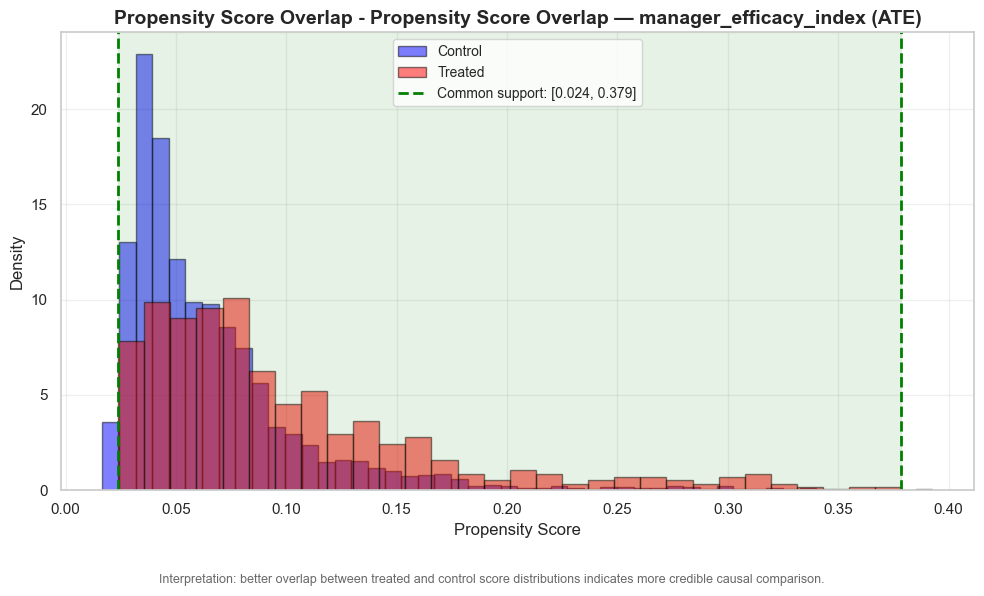

  ✓ Post-weighting balance: all 32 covariates balanced (|SMD| < 0.1)
  [manager_efficacy_index] ATE = 0.3982 (95% CI: [0.3213, 0.4752]), p = 0.0000 ***, Cohen's d = 0.4740


,Parameter,Estimate,Std_Error,CI_Lower,CI_Upper,P_Value_Raw,Alpha
28,treatment,0.398223,0.03927,0.321256,0.475191,3.645104e-24,0.05



ANALYZING OUTCOME: workload_index_mgr


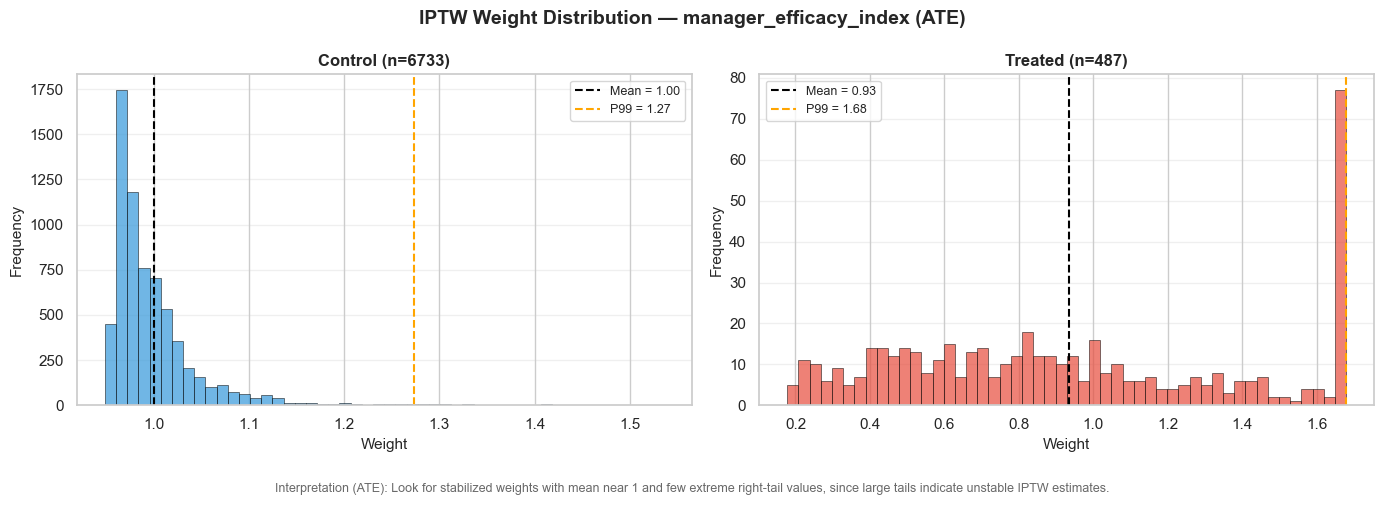

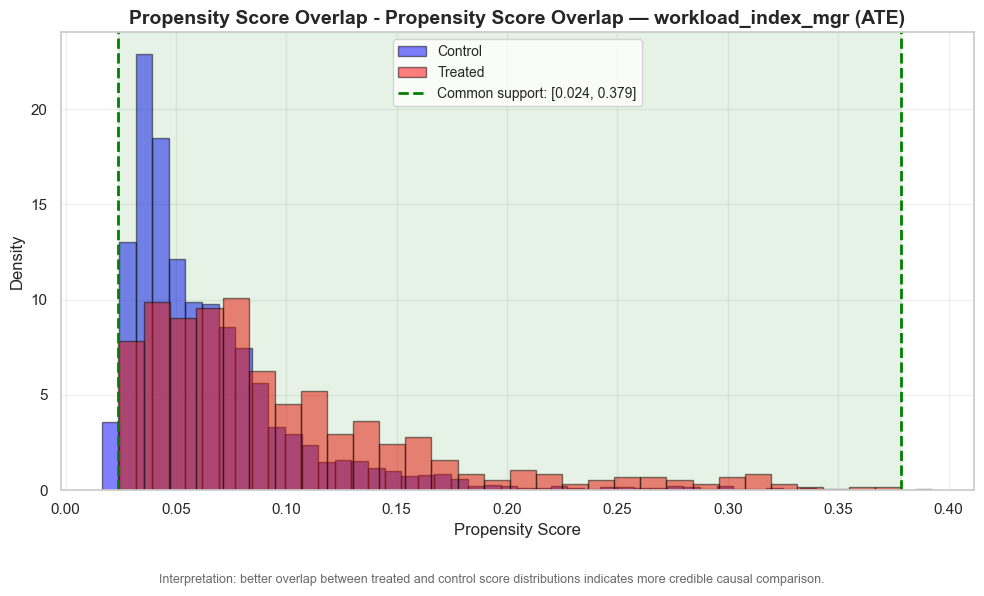

  ✓ Post-weighting balance: all 32 covariates balanced (|SMD| < 0.1)
  [workload_index_mgr] ATE = -0.0406 (95% CI: [-0.1233, 0.0421]), p = 0.3360 , Cohen's d = -0.0607


,Parameter,Estimate,Std_Error,CI_Lower,CI_Upper,P_Value_Raw,Alpha
28,treatment,-0.040593,0.042193,-0.123289,0.042104,0.336012,0.05



ANALYZING OUTCOME: turnover_intention_index_mgr


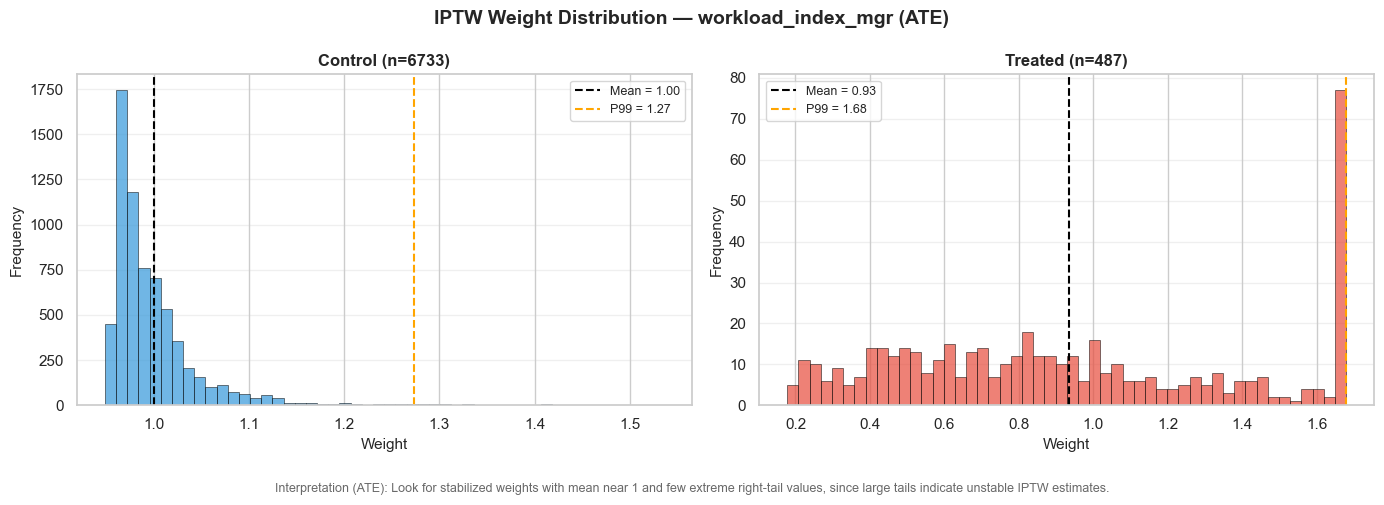

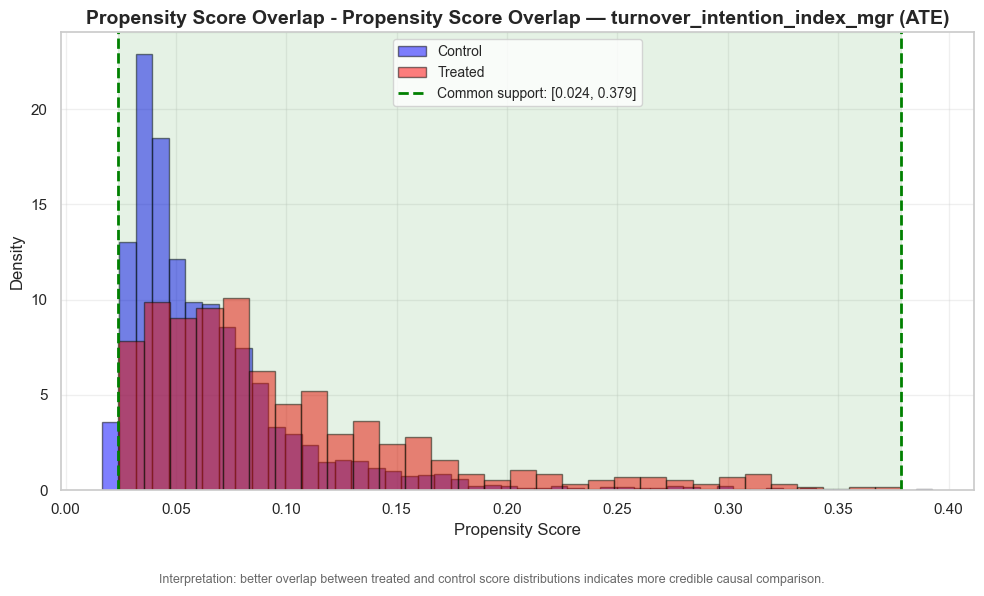

  ✓ Post-weighting balance: all 32 covariates balanced (|SMD| < 0.1)
  [turnover_intention_index_mgr] ATE = 0.2300 (95% CI: [0.1462, 0.3138]), p = 0.0000 ***, Cohen's d = 0.2685


,Parameter,Estimate,Std_Error,CI_Lower,CI_Upper,P_Value_Raw,Alpha
28,treatment,0.230027,0.042757,0.146225,0.313829,7.453607e-08,0.05



  IPTW + GEE: ATE Summary — Survey Outcomes (3 tests)
                     Outcome  Effect Estimand Std_Error CI_Lower CI_Upper P_Value Cohens_d Pct_Change Mean_Treatment Mean_Control    N    ESS P_Value_Corrected  Significant Significance Correction_Method
      manager_efficacy_index  0.3982      ATE    0.0393   0.3213   0.4752  0.0000   0.4740     11.85%         3.7833       3.3824 7220 7094.4            0.0000         True          ***            fdr_bh
          workload_index_mgr -0.0406      ATE    0.0422  -0.1233   0.0421  0.3360  -0.0607     -1.78%         3.1347       3.1914 7220 7094.4            0.3360        False                         fdr_bh
turnover_intention_index_mgr  0.2300      ATE    0.0428   0.1462   0.3138  0.0000   0.2685      9.11%         3.0523       2.7975 7220 7094.4            0.0000         True          ***            fdr_bh
  Significance: *** p<0.001, ** p<0.01, * p<0.05
  Correction: fdr_bh across 3 outcomes

  Summary table saved to c:\Users\U10085

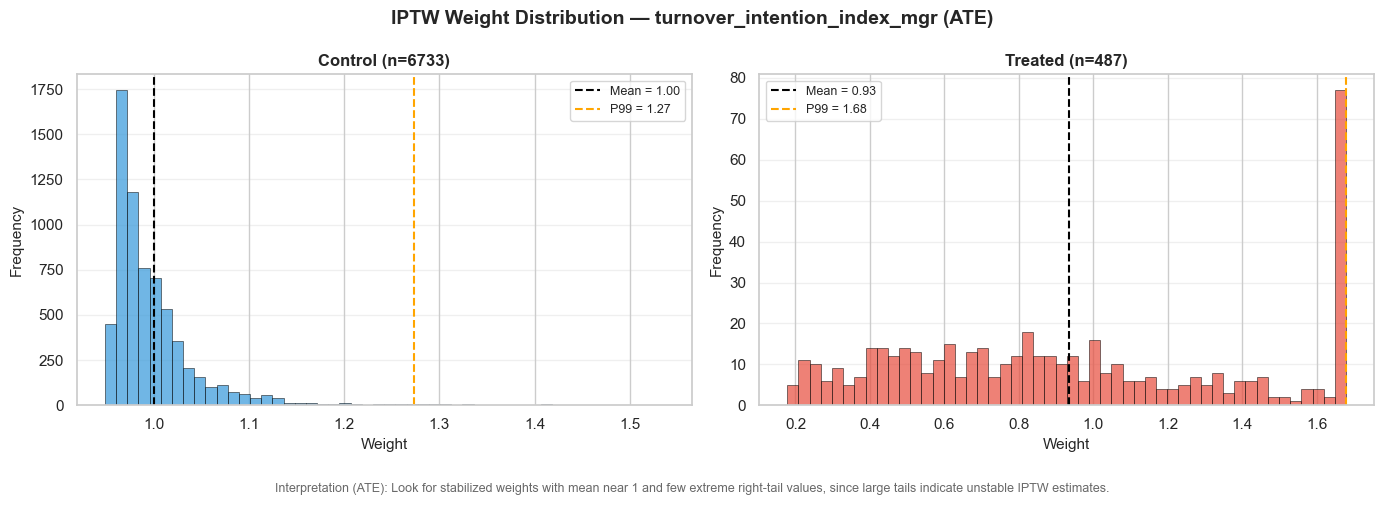

In [14]:
# =============================================================================
# ATE ANALYSIS — SURVEY OUTCOMES (IPTW + Doubly Robust GEE)
# =============================================================================

causal_model = CausalInferenceModel()

survey_results = {}

for o in survey_outcomes:
    print("\n" + "=" * 60)
    print(f"ANALYZING OUTCOME: {o}")
    print("=" * 60)
    survey_results[o] = causal_model.analyze_treatment_effect(
        data=data,
        outcome_var=o,
        treatment_var=treatment,
        estimand='ATE',
        categorical_vars=categorical_vars,
        binary_vars=binary_vars,
        continuous_vars=continuous_vars,
        cluster_var='team_id',
        baseline_var=baseline_vars.get(o),
        project_path=base_dir / "results",
        trim_quantile=0.99,
        analysis_name=f"IPTW_GEE_{o}",
        correction_method='fdr_bh',
        alpha=0.05
    )
    display(survey_results[o]['coefficients_df'])

survey_summary = CausalInferenceModel.build_summary_table(
    survey_results,
    title="IPTW + GEE: ATE Summary — Survey Outcomes (3 tests)",
    save_path=str(base_dir / "results" / "ate_summary_survey.xlsx")
)

# =============================================================================
# INDEPENDENT POST-WEIGHTING BALANCE VERIFICATION — Survey
# =============================================================================

def verify_balance(results_dict, family_label, cd_instance, treatment_var,
                   categorical_vars, binary_vars, continuous_vars,
                   exclude_cols=None):
    """
    Independent cross-check of post-weighting covariate balance.
    Uses CausalDiagnostics.compute_balance_df() on the weighted_df returned
    by analyze_treatment_effect / analyze_survival_effect, and compares
    against the model's balance_df.
    """
    # Default exclusion list for GEE outcomes
    if exclude_cols is None:
        exclude_cols = []

    for outcome, res in results_dict.items():
        wdf = res.get('weighted_df')
        if wdf is None:
            print(f"  [{outcome}] No weighted_df in results - skipping.")
            continue

        # Identify balance covariates (everything except outcome, ID, weight, PS)
        always_exclude = {treatment_var, 'id', 'team_id', 'propensity_score', 'iptw'}
        always_exclude.update(exclude_cols)
        always_exclude.add(outcome)
        balance_cols = [c for c in wdf.columns if c not in always_exclude]

        independent_balance = cd_instance.compute_balance_df(
            data=wdf,
            controls=balance_cols,
            treatment=treatment_var,
            weights=wdf['iptw'],
            already_encoded=True,
        )

        # Flag any covariates with weighted |SMD| > 0.1
        imbalanced = independent_balance[independent_balance['Weighted SMD'].abs() > 0.1]
        n_imbal = len(imbalanced)

        model_bal = res['balance_df']
        n_model_imbal = model_bal['balanced_after_weighting'].eq(False).sum() if 'balanced_after_weighting' in model_bal.columns else '?'

        status = '\u2705' if n_imbal == 0 else '\u26a0\ufe0f'
        print(f"  {status} [{outcome}]  Independent imbalanced: {n_imbal}  |  Model imbalanced: {n_model_imbal}")
        if n_imbal > 0:
            display(imbalanced)

print('=' * 60)
print('BALANCE VERIFICATION — Survey Outcomes (ATE)')
print('=' * 60)
verify_balance(survey_results, 'Survey', cd, treatment,
               categorical_vars, binary_vars, continuous_vars)

In [15]:
# =============================================================================
# E-VALUE SENSITIVITY ANALYSIS — Survey Outcomes (ATE)
# =============================================================================

print("\n" + "=" * 70)
print("E-VALUE SENSITIVITY ANALYSIS — Survey Outcomes (ATE)")
print("=" * 70)

# For survey outcomes (continuous), use Cohen's d
survey_evalues = CausalInferenceModel.compute_evalues_from_results(
    survey_results,
    effect_type="cohens_d"
)

survey_evalues.to_excel(base_dir / "results" / "ate_evalue_survey.xlsx", index=False)


E-VALUE SENSITIVITY ANALYSIS — Survey Outcomes (ATE)

  E-VALUE SENSITIVITY ANALYSIS
                     Outcome Effect_Type  Effect_Value  Effect_RR  E_Value_Point  E_Value_CI Robustness      P_Value  Significant
      manager_efficacy_index    cohens_d      0.474021   1.539349       2.450527    2.013999   Moderate 3.645104e-24         True
          workload_index_mgr    cohens_d     -0.060734   1.056824       1.301882    1.483182  Very Weak 3.360118e-01        False
turnover_intention_index_mgr    cohens_d      0.268482   1.276751       1.871176    1.545536       Weak 7.453607e-08         True
  Interpretation Guide:
    E-value ≥ 3.0 : Strong robustness to unmeasured confounding
    E-value 2.0-3.0: Moderate robustness
    E-value 1.5-2.0: Weak robustness - interpret with caution
    E-value < 1.5 : Very weak - easily explained by confounding

  Per-Outcome Interpretations (significant results only):
----------------------------------------------------------------------

  manage

In [48]:
# =============================================================================
# PRESERVE ATE SURVEY RESULTS
# =============================================================================
# The ATT analysis below reuses the same variable names (survey_results, etc.).
# Copy ATE outputs now so they remain available for the comparison section.

ate_survey_results = {k: v for k, v in survey_results.items()}
ate_survey_summary = survey_summary.copy()
ate_survey_evalues = survey_evalues.copy()

# Friendly display names for outcome variables (used by all summary generators)
outcome_descriptions = {
    'manager_efficacy_index': 'Manager Efficacy Index',
    'workload_index_mgr': 'Workload Index',
    'turnover_intention_index_mgr': 'Turnover Intention Index',
    'retention': 'Manager Retention',
}

# Outcome valence: "positive" = higher is better (default), "negative" = higher is worse
outcome_valence = {
    'workload_index_mgr': 'negative',  # higher workload = worse
    # all others default to 'positive'
}

print("✅ ATE survey results preserved. Outcome descriptions and valence defined.")

✅ ATE survey results preserved. Outcome descriptions and valence defined.


In [49]:
# =============================================================================
# ATE TECHNICAL SUMMARY — Survey Outcomes
# =============================================================================
from IPython.display import display, Markdown

ate_md = "### ATE Technical Summary — Survey Outcomes\n"
ate_md += "*Note: None of these results generalize to poor performers.*\n\n"

ate_md += CausalInferenceModel.generate_gee_summary_report(
    summary_df=ate_survey_summary,
    evalues_df=ate_survey_evalues,
    results_dict=ate_survey_results,
    estimand="ATE",
    family_label="Survey Outcomes (Continuous)",
    outcome_descriptions=outcome_descriptions,
)

display(Markdown(ate_md))

### ATE Technical Summary — Survey Outcomes
*Note: None of these results generalize to poor performers.*

#### Survey Outcomes (Continuous) (3 tests, FDR_BH-corrected)

| Outcome | ATE | 95% CI | p (corrected) | Cohen's d | Significant? |
|---------|-----|--------|---------------|-----------|-------------|
| Manager Efficacy Index | **+0.41** | [0.34, 0.48] | < 0.0001 | 0.50 | Yes *** |
| Workload Index | **-0.05** | [-0.12, 0.03] | 0.241 | -0.04 | No |
| Turnover Intention Index | **+0.26** | [0.18, 0.33] | < 0.0001 | 0.30 | Yes *** |

**Manager Efficacy Index**
- ATE of **+0.41** (Cohen's d = 0.50), representing a **+12.4% relative improvement** vs. controls

**Workload Index** — *No effect detected*
- ATE of **-0.05**, not statistically significant (p = 0.241)

**Turnover Intention Index**
- ATE of **+0.26** (Cohen's d = 0.30), representing a **+10.0% relative improvement** vs. controls

#### Post-Weighting Balance Verification
- ✅ All 3 outcomes passed balance verification (0 imbalanced covariates).
- IPTW successfully balanced observed confounders across treatment groups.

#### E-Value Sensitivity Analysis

| Outcome | E-Value Point | E-Value CI | Robustness |
|---------|---------------|------------|------------|
| Manager Efficacy Index | **2.53** | **2.07** | Moderate |
| Workload Index | 1.24 | 1.48 | Very Weak (ns) |
| Turnover Intention Index | **1.94** | **1.65** | Weak |

**Significant outcome interpretations:**

- **Manager Efficacy Index:** E-value = 2.53. An unmeasured confounder would need risk ratio associations of at least 2.53 with both treatment and outcome to explain away this effect. This represents moderate robustness. The E-value for the confidence interval bound is 2.07, meaning a confounder of this strength could shift the CI to include the null.

- **Turnover Intention Index:** E-value = 1.94. A relatively weak unmeasured confounder (RR ≈ 1.94) could potentially explain this effect. Interpret with caution. The E-value for the confidence interval bound is 1.65, meaning a confounder of this strength could shift the CI to include the null.


---

## What if we couldn't sufficiently balance the model for estimating ATE?

### Estimating Average Treatment Effect on the Treated (ATT) using IPTW + GEE
---

### When to Use ATT Instead of ATE

| Consideration | ATE | ATT |
|---------------|-----|-----|
| **Target population** | Full population (treated + untreated) | Only those who received treatment |
| **Research question** | "What would happen if we rolled this out to everyone?" | "Did the program work for those who actually participated?" |
| **Overlap requirement** | Strict: every covariate profile needs both treated and control individuals | Relaxed: only need controls that resemble the treated |
| **Typical use case** | Policy decisions about universal rollout | Evaluating a voluntary or targeted program |
| **When treated group is small** | Problematic — requires extrapolating to dissimilar individuals | Natural fit — you're only generalizing to the treated |

**Use ATT when:**
- The treated group is small relative to controls
- Many controls have no comparable treated individual (but the reverse is fine)
- You want to evaluate whether the treatment worked *for those who received it*, not whether it would work for everyone
- Full-population overlap is poor, but one-directional overlap (controls → treated) is adequate

---

### What Stays the Same

The following elements are **identical** to the ATE approach:

- GEE model structure: $g\big(E[Y_i]\big) = \beta_0 + \beta_1 \cdot Treatment_i + \beta_2 \cdot X_i$
- Link functions: identity for continuous outcomes, logit for binary
- Propensity score estimation: $\hat{e}_i = P(Treatment_i = 1 \mid X_i)$
- Clustering by team (manager ID) with sandwich standard errors
- Doubly robust property: consistent if either PS model or outcome model is correct
- Weight trimming and propensity score clipping mechanics
- Multiple testing correction across outcomes

---

### What Changes: The Weights

This is the **only substantive difference** — the weight formula determines the estimand.

| Group | ATE Weights | ATT Weights |
|-------|-------------|-------------|
| **Treated** | $w_i = 1 \;/\; \hat{e}_i$ | $w_i = 1$ |
| **Control** | $w_i = 1 \;/\; (1 - \hat{e}_i)$ | $w_i = \hat{e}_i \;/\; (1 - \hat{e}_i)$ |
| **What it does** | Reweights **both** groups to represent full population | Reweights **only controls** to match the treated group |

**Intuition for ATT weights:**
- Treated individuals already represent themselves — no reweighting needed (weight = 1)
- Controls are reweighted to *look like* the treated group:
  - High propensity score → "this control looks like someone who would have been treated" → upweight
  - Low propensity score → "this control looks nothing like treated individuals" → downweight
- The weighted control group becomes a synthetic comparison group that mirrors the treated on observed covariates

**Stabilization under ATT:**
- Treated: $w_i^{stab} = 1$ (unchanged)
- Control: $w_i^{stab} = \bar{p} \cdot \hat{e}_i \;/\; (1 - \hat{e}_i)$

Stabilization only affects control weights under ATT, since treated weights are already fixed at 1.

---

### What Changes: The Positivity Assumption

| Assumption | ATE Requirement | ATT Requirement |
|------------|-----------------|-----------------|
| **Positivity** | $0 < P(T=1 \mid X) < 1$ for **all** individuals | $P(T=0 \mid X) > 0$ for **treated** individuals only |
| **In plain language** | Every covariate profile needs both treated and control individuals | Every treated individual needs comparable controls |
| **What can be violated** | Neither direction can have gaps | Controls with no comparable treated are fine |

This relaxed requirement is why ATT is often feasible when ATE is not — you only need overlap in one direction.

---

### Interpretation Differences

**Continuous outcomes:**
- ATE: "On average across the population, treatment shifts the outcome by $\beta_1$ units"
- ATT: "On average among those who received treatment, treatment shifts the outcome by $\beta_1$ units"

**Binary outcomes:**
- ATE: $e^{\beta_1}$ = odds ratio averaged across the full population
- ATT: $e^{\beta_1}$ = odds ratio averaged across the treated subpopulation

**Key implication:** ATT and ATE will differ when treatment effects are heterogeneous — i.e., when the effect varies across individuals. If treated individuals would benefit more (or less) from treatment than the average person, ATT ≠ ATE.

---

### Summary: ATE vs. ATT Design Choices

| Design Choice | ATE | ATT |
|---------------|-----|-----|
| **Treated weights** | $1 / \hat{e}_i$ | $1$ |
| **Control weights** | $1 / (1 - \hat{e}_i)$ | $\hat{e}_i / (1 - \hat{e}_i)$ |
| **Stabilized treated** | $\bar{p} / \hat{e}_i$ | $1$ |
| **Stabilized control** | $(1-\bar{p}) / (1 - \hat{e}_i)$ | $\bar{p} \cdot \hat{e}_i / (1 - \hat{e}_i)$ |
| **Target population** | Everyone | Treated only |
| **Overlap needed** | Both directions | Controls → Treated only |
| **Typical weight range** | Higher variance (both groups reweighted) | Lower variance (only controls reweighted) |
| **When to prefer** | Universal policy decisions | Evaluating voluntary/targeted programs |

All other model components — GEE structure, clustering, sandwich SEs, doubly robust estimation, trimming, clipping, outcome family detection, FDR correction — remain identical.


ANALYZING OUTCOME: manager_efficacy_index


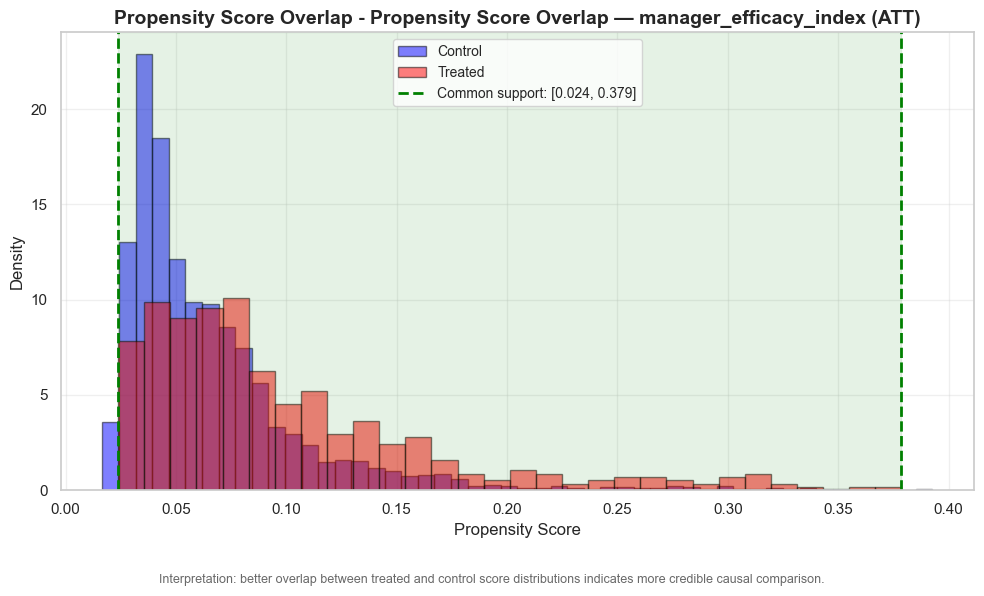

  ✓ Post-weighting balance: all 32 covariates balanced (|SMD| < 0.1)
  [manager_efficacy_index] ATT = 0.4119 (95% CI: [0.3423, 0.4815]), p = 0.0000 ***, Cohen's d = 0.4993


,Parameter,Estimate,Std_Error,CI_Lower,CI_Upper,P_Value_Raw,Alpha
28,treatment,0.411923,0.035517,0.342312,0.481534,4.216315e-31,0.05



ANALYZING OUTCOME: workload_index_mgr


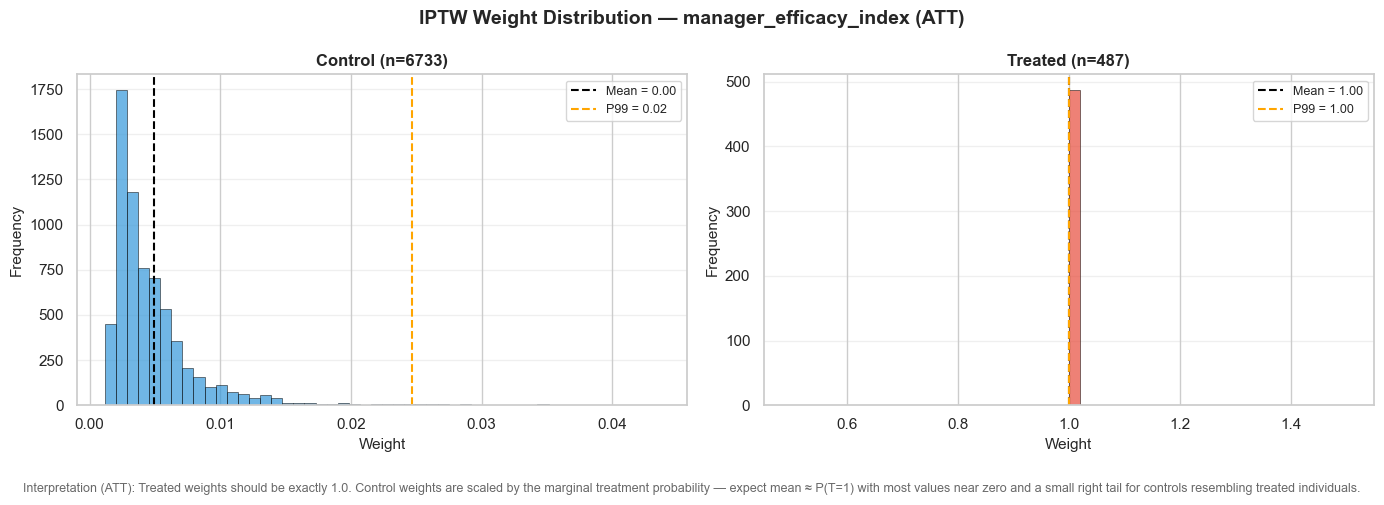

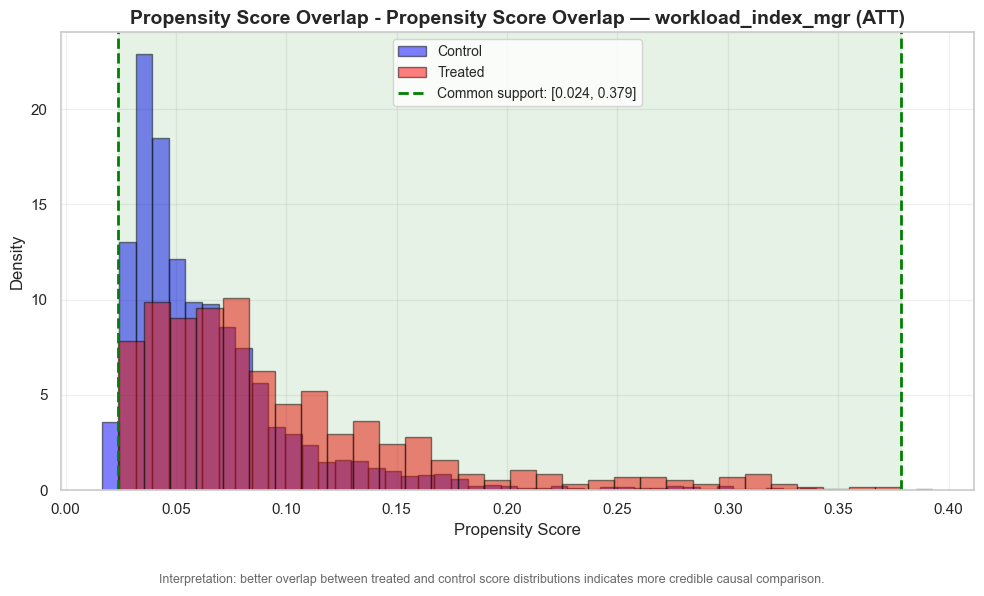

  ✓ Post-weighting balance: all 32 covariates balanced (|SMD| < 0.1)
  [workload_index_mgr] ATT = -0.0458 (95% CI: [-0.1224, 0.0308]), p = 0.2415 , Cohen's d = -0.0426


,Parameter,Estimate,Std_Error,CI_Lower,CI_Upper,P_Value_Raw,Alpha
28,treatment,-0.045796,0.039097,-0.122425,0.030834,0.241471,0.05



ANALYZING OUTCOME: turnover_intention_index_mgr


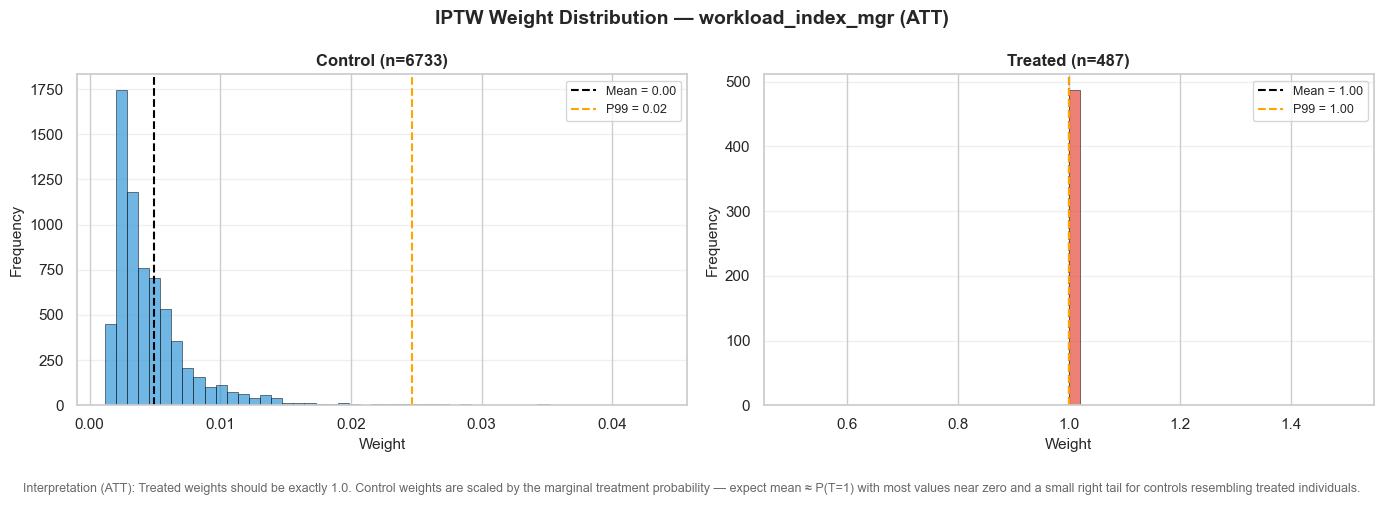

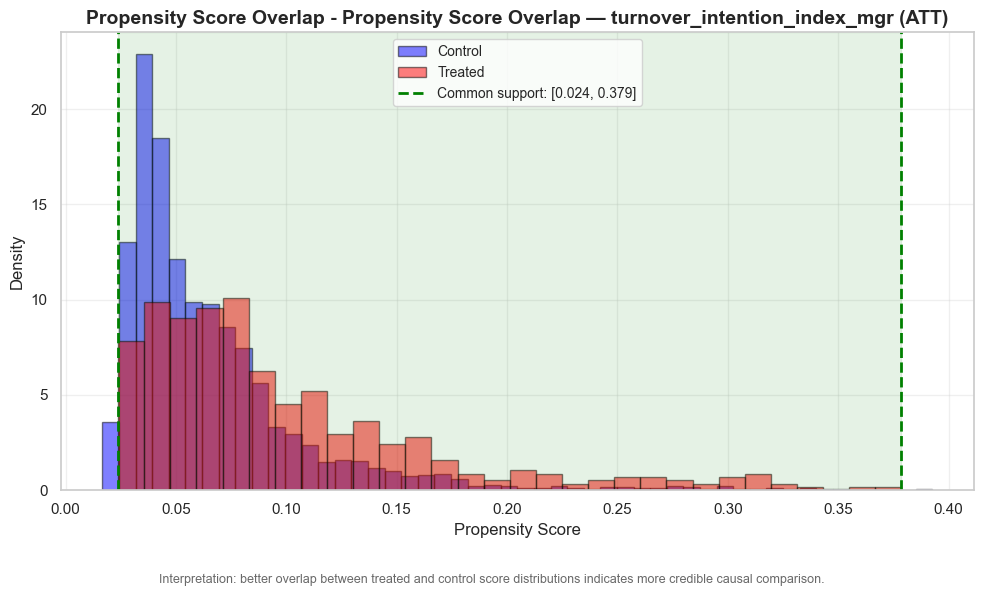

  ✓ Post-weighting balance: all 32 covariates balanced (|SMD| < 0.1)
  [turnover_intention_index_mgr] ATT = 0.2582 (95% CI: [0.1839, 0.3325]), p = 0.0000 ***, Cohen's d = 0.2951


,Parameter,Estimate,Std_Error,CI_Lower,CI_Upper,P_Value_Raw,Alpha
28,treatment,0.258218,0.037903,0.183928,0.332507,9.590677e-12,0.05



  IPTW + GEE: ATT Summary — Survey Outcomes (3 tests)
                     Outcome  Effect Estimand Std_Error CI_Lower CI_Upper P_Value Cohens_d Pct_Change Mean_Treatment Mean_Control    N   ESS P_Value_Corrected  Significant Significance Correction_Method
      manager_efficacy_index  0.4119      ATT    0.0355   0.3423   0.4815  0.0000   0.4993     12.38%         3.7992       3.3806 7220 554.8            0.0000         True          ***            fdr_bh
          workload_index_mgr -0.0458      ATT    0.0391  -0.1224   0.0308  0.2415  -0.0426     -1.26%         3.1378       3.1777 7220 554.8            0.2415        False                         fdr_bh
turnover_intention_index_mgr  0.2582      ATT    0.0379   0.1839   0.3325  0.0000   0.2951      9.98%         3.0614       2.7835 7220 554.8            0.0000         True          ***            fdr_bh
  Significance: *** p<0.001, ** p<0.01, * p<0.05
  Correction: fdr_bh across 3 outcomes

  Summary table saved to c:\Users\U1008500\D

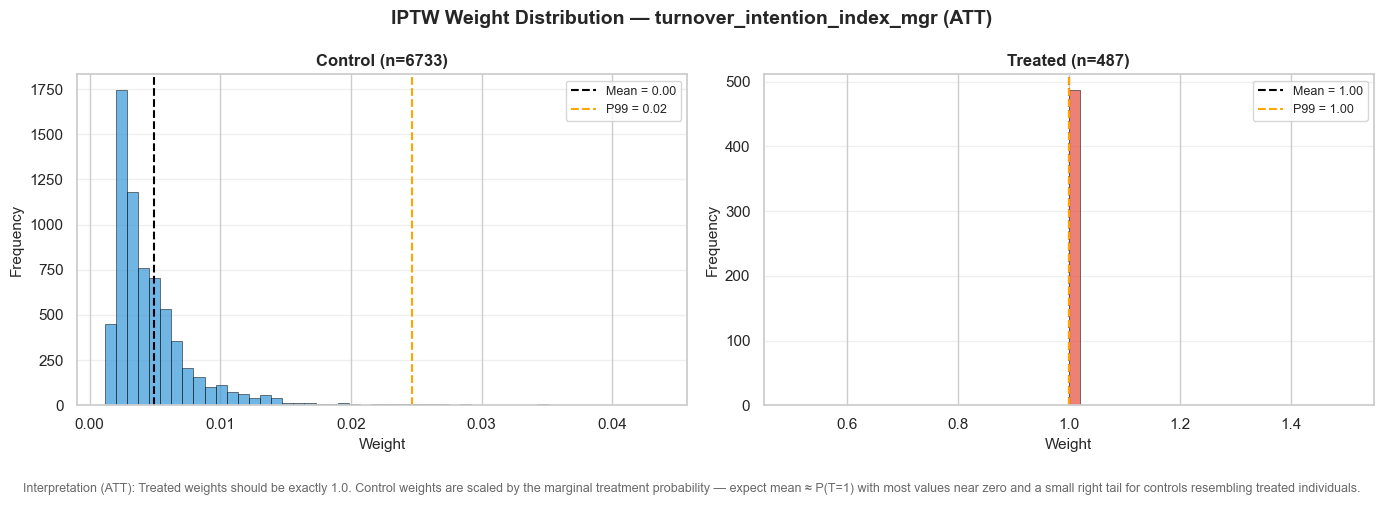

In [50]:
# =============================================================================
# ATT ANALYSIS — SURVEY OUTCOMES (IPTW + Doubly Robust GEE)
# =============================================================================

causal_model = CausalInferenceModel()

survey_results = {}

for o in survey_outcomes:
    print("\n" + "=" * 60)
    print(f"ANALYZING OUTCOME: {o}")
    print("=" * 60)
    survey_results[o] = causal_model.analyze_treatment_effect(
        data=data,
        outcome_var=o,
        treatment_var=treatment,
        estimand='ATT',
        categorical_vars=categorical_vars,
        binary_vars=binary_vars,
        continuous_vars=continuous_vars,
        cluster_var='team_id',
        baseline_var=baseline_vars.get(o),
        project_path=base_dir / "results",
        trim_quantile=0.99,
        analysis_name=f"IPTW_GEE_{o}",
        correction_method='fdr_bh',
        alpha=0.05
    )
    display(survey_results[o]['coefficients_df'])

survey_summary = CausalInferenceModel.build_summary_table(
    survey_results,
    title="IPTW + GEE: ATT Summary — Survey Outcomes (3 tests)",
    save_path=str(base_dir / "results" / "att_summary_survey.xlsx")
)

# =============================================================================
# INDEPENDENT POST-WEIGHTING BALANCE VERIFICATION — Survey (ATT)
# =============================================================================

print('=' * 60)
print('BALANCE VERIFICATION — Survey Outcomes (ATT)')
print('=' * 60)
verify_balance(survey_results, 'Survey', cd, treatment,
               categorical_vars, binary_vars, continuous_vars)

In [51]:
# =============================================================================
# E-VALUE SENSITIVITY ANALYSIS — Survey Outcomes (ATT)
# =============================================================================

print("\n" + "=" * 70)
print("E-VALUE SENSITIVITY ANALYSIS — Survey Outcomes (ATT)")
print("=" * 70)

survey_evalues = CausalInferenceModel.compute_evalues_from_results(
    survey_results,
    effect_type="cohens_d"
)

survey_evalues.to_excel(base_dir / "results" / "att_evalue_survey.xlsx", index=False)


E-VALUE SENSITIVITY ANALYSIS — Survey Outcomes (ATT)

  E-VALUE SENSITIVITY ANALYSIS
                     Outcome Effect_Type  Effect_Value  Effect_RR  E_Value_Point  E_Value_CI Robustness      P_Value  Significant
      manager_efficacy_index    cohens_d      0.499321   1.575200       2.527069    2.071912   Moderate 4.216315e-31         True
          workload_index_mgr    cohens_d     -0.042567   1.039496       1.242118    1.480807  Very Weak 2.414711e-01        False
turnover_intention_index_mgr    cohens_d      0.295113   1.308070       1.942875    1.646302       Weak 9.590677e-12         True
  Interpretation Guide:
    E-value ≥ 3.0 : Strong robustness to unmeasured confounding
    E-value 2.0-3.0: Moderate robustness
    E-value 1.5-2.0: Weak robustness - interpret with caution
    E-value < 1.5 : Very weak - easily explained by confounding

  Per-Outcome Interpretations (significant results only):
----------------------------------------------------------------------

  manage

In [ ]:
# =============================================================================
# ATT TECHNICAL SUMMARY — Survey Outcomes
# =============================================================================
###NOTE - REMOVE THIS FUNCTION BEFORE FINALIZATION, JUST INPUT A MANUALLY MARKDOWN SUMMARY

att_md = "### ATT Technical Summary — Survey Outcomes\n"
att_md += "*Note: These results apply only to treated individuals.*\n\n"

att_md += CausalInferenceModel.generate_gee_summary_report(
    summary_df=survey_summary,
    evalues_df=survey_evalues,
    results_dict=survey_results,
    estimand="ATT",
    family_label="Survey Outcomes (Continuous)",
    outcome_descriptions=outcome_descriptions,
)

display(Markdown(att_md))

### ATT Technical Summary — Survey Outcomes
*Note: These results apply only to treated individuals.*

#### Survey Outcomes (Continuous) (3 tests, FDR_BH-corrected)

| Outcome | ATT | 95% CI | p (corrected) | Cohen's d | Significant? |
|---------|-----|--------|---------------|-----------|-------------|
| Manager Efficacy Index | **+0.41** | [0.34, 0.48] | < 0.0001 | 0.50 | Yes *** |
| Workload Index | **-0.05** | [-0.12, 0.03] | 0.241 | -0.04 | No |
| Turnover Intention Index | **+0.26** | [0.18, 0.33] | < 0.0001 | 0.30 | Yes *** |

**Manager Efficacy Index**
- ATT of **+0.41** (Cohen's d = 0.50), representing a **+12.4% relative improvement** vs. controls

**Workload Index** — *No effect detected*
- ATT of **-0.05**, not statistically significant (p = 0.241)

**Turnover Intention Index**
- ATT of **+0.26** (Cohen's d = 0.30), representing a **+10.0% relative improvement** vs. controls

#### Post-Weighting Balance Verification
- ✅ All 3 outcomes passed balance verification (0 imbalanced covariates).
- IPTW successfully balanced observed confounders across treatment groups.

#### E-Value Sensitivity Analysis

| Outcome | E-Value Point | E-Value CI | Robustness |
|---------|---------------|------------|------------|
| Manager Efficacy Index | **2.53** | **2.07** | Moderate |
| Workload Index | 1.24 | 1.48 | Very Weak (ns) |
| Turnover Intention Index | **1.94** | **1.65** | Weak |

**Significant outcome interpretations:**

- **Manager Efficacy Index:** E-value = 2.53. An unmeasured confounder would need risk ratio associations of at least 2.53 with both treatment and outcome to explain away this effect. This represents moderate robustness. The E-value for the confidence interval bound is 2.07, meaning a confounder of this strength could shift the CI to include the null.

- **Turnover Intention Index:** E-value = 1.94. A relatively weak unmeasured confounder (RR ≈ 1.94) could potentially explain this effect. Interpret with caution. The E-value for the confidence interval bound is 1.65, meaning a confounder of this strength could shift the CI to include the null.


In [ ]:
# =============================================================================
# ATE vs. ATT COMPARISON — Survey Outcomes
# =============================================================================
###NOTE - REMOVE THIS FUNCTION BEFORE FINALIZATION, JUST INPUT A MANUALLY MARKDOWN SUMMARY

comparison_md = "## ATE vs. ATT Comparison — Survey Outcomes\n\n"
comparison_md += CausalInferenceModel.generate_comparison_table(
    ate_summary=ate_survey_summary,
    att_summary=survey_summary,
    ate_evalues=ate_survey_evalues,
    att_evalues=survey_evalues,
    ate_results=ate_survey_results,
    att_results=survey_results,
    outcome_descriptions=outcome_descriptions,
)

display(Markdown(comparison_md))

## ATE vs. ATT Comparison — Survey Outcomes

### Side-by-Side Comparison

| Outcome | ATE | ATT | Difference |
|---------|-----|-----|------------|
| **Manager Efficacy Index** | +0.41 (Cohen's d = 0.50) | +0.41 (Cohen's d = 0.50) | ATT slightly smaller |
| **Workload Index** | -0.05 (Cohen's d = -0.04) (ns) | -0.05 (Cohen's d = -0.04) (ns) | ATT slightly smaller |
| **Turnover Intention Index** | +0.26 (Cohen's d = 0.30) | +0.26 (Cohen's d = 0.30) | ATT slightly smaller |

### Key Observations

1. **Both estimands tell the same qualitative story**: the direction and significance pattern is consistent across ATE and ATT for all outcomes.

### E-Value Comparison

| Outcome | ATE E-Value | ATT E-Value | Difference |
|---------|-------------|-------------|------------|
| **Manager Efficacy Index** | 2.53 | 2.53 | Similar robustness |
| **Turnover Intention Index** | 1.94 | 1.94 | Similar robustness |


### Interpreting ATE vs. ATT Differences

**Conceptual Distinction:**

- **ATE (Average Treatment Effect):** Estimates the effect of the training program if we could randomly assign *everyone* in the population to receive it. This answers: "What would happen if we rolled this program out universally?"

- **ATT (Average Treatment on the Treated):** Estimates the effect of the training program specifically for *those who actually received it*. This answers: "What was the effect for the managers who were trained?"

The key difference: ATE generalizes to the full population, while ATT focuses only on the treated group. In observational studies, these can differ if treated individuals respond differently to the program than untreated individuals would.

---

### Which Estimand Should You Use?

**For L&D decision-making, ATE is typically more appropriate** because:
- It answers the policy-relevant question: "What happens if we scale this program?"
- It generalizes to the full manager population, not just those who happened to be trained
- It's more conservative (smaller effects), reducing the risk of over-promising

**ATT is useful for:**
- Understanding whether the program worked *for the people who actually got it* (program evaluation)
- Teaching purposes (comparing estimands, as we're doing here)
- Situations where you only care about the treated group (e.g., post-hoc evaluation of a completed pilot)

**Bottom line:** The ATE results are the ones you should lead with when making recommendations about program expansion. The ATT results confirm that the program worked well for those who received it, and the E-value comparison illustrates an important methodological principle: larger effects are more robust to confounding by construction, but that robustness advantage should be interpreted alongside — not instead of — careful consideration of the selection process that generated the larger effects.

---

---

## Retention Analysis — Survival Modeling (IPTW + Cox PH with Time Interaction)

### Why Survival Analysis Instead of Binary GEE?

The survey analysis above modeled three continuous outcomes via IPTW + GEE. For retention, we now switch to **survival analysis** (Cox proportional hazards) instead of treating retention as multiple binary outcomes. Here's why:

1. **Correlated outcomes**: Binary retention flags at 3, 6, 9, and 12 months are nested — anyone retained at 12 months was also retained at all earlier points. Separate models ignore this dependency.
2. **Information loss**: Binary flags discard exact departure timing. A manager who left on day 91 is treated identically to one who left on day 180.
3. **Multiple testing burden**: Four correlated tests require FDR correction, reducing power.
4. **Censoring**: Not all managers are observed for the full 12 months. Some are still employed when data collection ends (right-censored). Binary outcomes can't properly handle censoring — survival analysis can.

**Cox proportional hazards** addresses all four:
- A **single model** captures the full time-to-event trajectory
- **Exact departure timing** is used (days, not quarters)
- **One test** for the treatment effect — no multiple testing penalty
- **Censoring is handled correctly** — managers still employed contribute information up to their last observation
- The **hazard ratio (HR)** has a natural interpretation: HR < 1 means trained managers depart at a lower rate

---

### Method: IPTW-Weighted Cox Models with Time Interaction

Same IPTW infrastructure as the survey analysis (propensity scores, stabilized weights, trimming at 99th percentile), but the outcome model is **Cox PH with time interaction terms** instead of GEE. We use **time interaction models** because training effects often vary over time — strong early protection that fades later. A single overall Cox model would mask this temporal pattern by averaging across periods.

**Time interaction approach:**
- Split follow-up into periods: 0–3 months, 3–6 months, 6–9 months, 9–12 months
- Fit a **single IPTW-weighted Cox model** with treatment × period interaction terms
- Each period gets its own hazard ratio (HR) estimated from the combined model
- Reveals **when** training is effective, not just **whether** it's effective
- Handles non-proportional hazards by design — the interaction terms explicitly model how the treatment effect changes over time

**Categorical vs. continuous time interaction:**

Two specifications are possible for the time interaction term:

- **Continuous interaction** (`treatment × time_months`): Models the treatment effect as a **linear trend** over time — the HR changes by a fixed amount per month. Parsimonious (only 2 parameters), but assumes the effect decays monotonically and at a constant rate.
- **Categorical interaction** (`treatment × period`): Models the treatment effect **separately for each period** — no assumption about the shape of the trend. More flexible (one parameter per period), but requires sufficient events in each period.

We use **categorical interactions** for three reasons:

1. **Seasonality suggests non-linearity**: We know baseline attrition has seasonal spikes (e.g., post-bonus, year-end). The training effect may interact with these spikes in non-linear ways that a linear trend would miss.
2. **Exploratory hypothesis**: We suspect the effect weakens over time but don't know the exact shape. Categorical interactions let the data reveal the pattern rather than imposing a linear assumption.
3. **Stakeholder communication**: Period-specific HRs (e.g., "HR = 0.587 in months 0–3") are more intuitive than a rate-of-change coefficient (e.g., "HR increases by 1.05 per month"). Each period's HR stands alone as a communicable finding.

The tradeoff is statistical power — categorical interactions require more parameters and need sufficient events per period × treatment cell. We verified this was satisfied before fitting (710 control events and 27 treated events in the first period alone).

**Key advantage over standard Cox:** The proportional hazards (PH) assumption requires that the hazard ratio remain constant over time. When this is violated (e.g., due to seasonality or treatment effect decay), a standard Cox model produces a single averaged HR that may not apply at any specific time point. Time interaction models directly address this by allowing the HR to vary across periods.

---

### The Cox Proportional Hazards Model with Time Interaction

Let:

- $T_i$ = time to departure (in days) for individual $i$
- $\delta_i$ = event indicator (1 if departed, 0 if censored/still employed)
- $Treatment_i$ = 1 if individual $i$ participated in training, 0 otherwise
- $Period_{ik}$ = indicator for time period $k$ (k = 1 for 3-6mo, 2 for 6-9mo, 3 for 9-12mo; 0-3mo is reference)
- $X_i$ = pre-treatment individual-level covariates
- $Team_i$ = the direct manager's team that individual $i$ belongs to (used for clustering)

The Cox model with categorical time interaction specifies the **hazard function**:

$$h_i(t) = h_0(t) \cdot \exp\big(\beta_1 \cdot Treatment_i + \sum_{k=1}^{3} \beta_{2k} \cdot Period_{ik} + \sum_{k=1}^{3} \beta_{3k} \cdot Treatment_i \times Period_{ik} + \beta_4 \cdot X_i\big)$$

Where:
- $h_i(t)$ = hazard of departure for individual $i$ at time $t$
- $h_0(t)$ = **baseline hazard function** (left unspecified, making Cox semi-parametric)
- $\beta_1$ = treatment effect in the **reference period** (0-3 months)
- $\beta_{2k}$ = baseline hazard adjustment for period $k$ (captures seasonality)
- $\beta_{3k}$ = **interaction term** — how much the treatment effect changes in period $k$ relative to reference
- $\exp(\beta_1 + \beta_{3k})$ = **hazard ratio (HR)** for period $k$
- $\beta_4 \cdot X_i$ = covariate adjustment for doubly robust estimation

**Person-period data structure:** To fit this model, the data are expanded to **person-period format** where each individual contributes one row per period they were at risk. The event indicator is 1 only in the period where departure occurred, and 0 in all prior periods. This allows the model to estimate conditional hazards — the risk of departing in each period, given survival to that period.

---

### Hazard Ratio Interpretation

For the reference period (0-3 months):
$$HR_{ref} = \exp(\beta_1)$$

For subsequent periods:
$$HR_k = \exp(\beta_1 + \beta_{3k})$$

- **HR = 1**: No treatment effect — trained and untrained managers depart at the same rate
- **HR < 1**: Training is protective — trained managers depart at a lower rate
  - Example: HR = 0.60 means trained managers have 60% of the departure hazard of untrained managers, or a **40% reduction** in departure risk
- **HR > 1**: Training is harmful — trained managers depart at a higher rate

**Important:** Each period's HR applies **only to that time window**. HR = 0.60 for 0–3 months means 40% hazard reduction during the first 3 months only, not the entire year.

**Testing for time-varying effects:** The interaction terms $\beta_{3k}$ test whether the treatment effect significantly changes over time. If all $\beta_{3k} \approx 0$, the effect is constant and a standard Cox model would suffice. If $\beta_{3k} > 0$ (HR increases over time), the protective effect is weakening — our core hypothesis.

---

### IPTW Weighting and Robust Standard Errors

Just as in the GEE analysis, we use **stabilized and trimmed ATE weights** to balance confounders:

- Propensity scores $\hat{e}_i = P(Treatment_i = 1 \mid X_i)$ are estimated via logistic regression
- **ATE weights:** Treated: $w_i = \bar{p} / \hat{e}_i$, Control: $w_i = (1 - \bar{p}) / (1 - \hat{e}_i)$
- Weights are **trimmed** at the 99th percentile to reduce influence of extreme values
- **Cluster-robust sandwich standard errors** account for within-team correlation

### Doubly Robust Estimation

The model is **doubly robust**: $\beta_1$ (and the period-specific HRs) consistently estimate the ATE if **at least one** of the following holds:

- The propensity score model $P(Treatment_i = 1 \mid X_i)$ is correctly specified, **or**
- The Cox outcome model (including $X_i$) is correctly specified

**Additional assumptions required:**
- **Positivity (overlap):** $0 < P(Treatment_i = 1 \mid X_i) < 1$ for all $i$
- **No unmeasured confounding:** All confounders are measured and included in $X_i$
- **Correct temporal ordering:** All covariates $X_i$ measured **prior to** treatment assignment
- **Independent censoring:** Censoring is independent of departure risk, conditional on covariates

---

### Kaplan-Meier Survival Curves

**Kaplan-Meier (KM) curves** show **absolute survival probabilities** over time:

$$\hat{S}(t) = \prod_{t_i \leq t} \left(1 - \frac{d_i}{n_i}\right)$$

Where $d_i$ = departures at time $t_i$ and $n_i$ = number at risk.

**IPTW-weighted KM curves:**
- Fit separate curves for treated and control groups
- Weight each individual by their IPTW weight
- Produces **marginal survival curves** — population-averaged retention trajectories

**Key limitation:** Built-in confidence bands are **not valid** with IPTW weights because they don't account for propensity score estimation uncertainty. We omit confidence bands and use Cox HR for inferential statistics.

---

## Summary: Model Design Choices

| Design Choice | Problem It Solves | What It Does |
|---------------|-------------------|--------------|
| **Time Interaction Terms** | Treatment effects often vary over time (strong early, weak later). Standard Cox assumes constant HR. | Adds treatment × period interactions to a single Cox model. Each period gets its own HR. Reveals when treatment is effective and tests whether the effect weakens over time. |
| **Person-Period Data Structure** | Need to model period-specific hazards while respecting temporal ordering | Expands data so each person contributes one row per period at risk. Event = 1 only in departure period. Allows conditional hazard estimation. |
| **IPTW Weighting** | Treatment assignment is non-random; need to balance confounders | Same weights as GEE analysis. Produces marginal (population-averaged) hazard ratios. |
| **Cluster-Robust SEs** | Teammates have correlated departure times | Adjusts standard errors for within-team correlation using sandwich estimator. |
| **Doubly Robust Estimation** | Uncertainty about model specification | Includes covariates in both propensity score and Cox models. Consistent if either is correct. |
| **Kaplan-Meier Curves** | Need to visualize absolute retention rates | Shows retention probability over time. IPTW-weighted for marginal estimates. Descriptive only. |
| **No Multiple Testing Correction** | Four time periods = four tests — do we need FDR correction? | No correction needed. We're characterizing one time-varying effect (retention), not testing four independent outcomes. The four HRs jointly describe when the effect occurs. Compare to survey analysis where we tested 3 separate outcomes (efficacy, intention, workload) and applied FDR correction. |

---

### Inference Notes

**Valid for inference:**
- ✅ Period-specific Cox HRs and confidence intervals (with cluster-robust SEs)
- ✅ Cox p-values for treatment effects within each period
- ✅ Tests of interaction terms (whether effect changes over time)

**Descriptive only:**
- ⚠️ Kaplan-Meier survival probabilities (e.g., 93.5% at 3 months)
- ⚠️ KM confidence bands (Greenwood variance ignores PS uncertainty)

**Why:** Cox robust SEs correctly account for IPTW weights via the sandwich estimator. KM variance estimators treat weights as fixed and ignore propensity score estimation uncertainty, making confidence intervals too narrow.

---

In [54]:
###############################################
# RETENTION ANALYSIS — VARIABLE DEFINITIONS
###############################################

# Survival outcome variables
time_var = 'days_observed'   # will be created by prepare_survival_data()
event_var = 'departed'       # will be created by prepare_survival_data()

# The single survival outcome uses 'retention' as its key in results dicts
retention_outcome_name = 'retention'

# Departure date column in the raw data
departure_date_col = 'exit_date'

# Study window (matches the data generator)
t0_date = '1-01-2026'           # study start — all managers begin observation Jan 1
study_end_date = '12-31-2026'   # study end — 365-day observation window

print(f"Time variable:      {time_var}")
print(f"Event variable:     {event_var}")
print(f"Departure date col: {departure_date_col}")
print(f"Study window:       {t0_date} → {study_end_date}")

Time variable:      days_observed
Event variable:     departed
Departure date col: exit_date
Study window:       1-01-2026 → 12-31-2026


In [55]:
# =============================================================================
# SURVIVAL DATA PREPARATION
# =============================================================================
# Convert exit_date → days_observed + departed
# This adds two columns to the dataframe: 'days_observed' (int) and 'departed' (0/1)

data = causal_model.prepare_survival_data(
    data=data,
    departure_date_col=departure_date_col,
    treatment_var=treatment,
    t0_date=t0_date,
    study_end_date=study_end_date,
    date_format='mixed',           # exit_date uses M/D/YYYY without zero-padding
    time_col_name=time_var,
    event_col_name=event_var,
)

# Quick validation: check that days_observed aligns with retention binary flags
print("\n--- Validation: survival columns vs. binary retention flags ---")
print(f"  departed=1 count:       {data[event_var].sum()}")
print(f"  retention_12month=0:    {(data['retention_12month'] == 0).sum()}")
print(f"  Match:                  {data[event_var].sum() == (data['retention_12month'] == 0).sum()}")


Parsed dates:
  T=0 (study start):  2026-01-01
  Study end:          2026-12-31
  Total window:       364 days
  Departure range:    2026-01-02 → 2026-12-30

SURVIVAL DATA PREPARATION SUMMARY
Study window:  2026-01-01  →  2026-12-31  (364 days)

SAMPLE:
  Total managers:          7220
  Treated (trained):       487 (6.7%)
  Control (untrained):     6733 (93.3%)

EVENTS (Departures):
  Total events:            1436 (19.9%)
  Events — Treated:        68 (14.0% of treated)
  Events — Control:        1368 (20.3% of control)

TIMING:
  Median days observed:    364 days
  Median days (events only): 86 days

DEPARTURE BY QUARTER:


,Control,Treated,Total
departure_quarter,,,
Q1 (Jan-Mar),714,27,741
Q2 (Apr-Jun),264,16,280
Q3 (Jul-Sep),200,13,213
Q4 (Oct-Dec),190,12,202
Censored,5365,419,5784
Total,6733,487,7220



CENSORED:
  Total censored:          5784 (80.1%)
  Censored — Treated:      419
  Censored — Control:      5365

✓ Survival columns added: 'days_observed' (days) and 'departed' (0/1)

--- Validation: survival columns vs. binary retention flags ---
  departed=1 count:       1436
  retention_12month=0:    1436
  Match:                  True


ANALYZING RETENTION: IPTW + Cox Time Interaction (ATE)


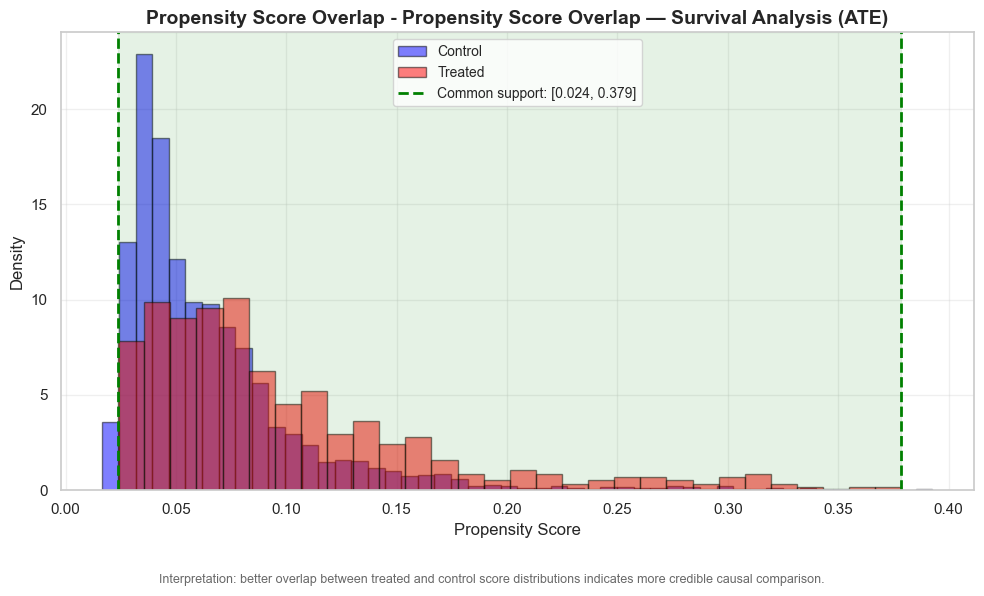

  ✓ Post-weighting balance: all 32 covariates balanced (|SMD| < 0.1)

COX PROPORTIONAL HAZARDS MODEL — TIME INTERACTION
Interaction type : categorical
Period breaks    : [0, 90, 180, 270, 365] (days)
Period labels    : ['0-3mo', '3-6mo', '6-9mo', '9-12mo']
Expanding to person-period format...
  Expanded from 7220 persons to 25884 person-periods
Reference period : 0-3mo

Model fitted     : 25,884 observations, 1436 events
Concordance      : 0.664

--- Proportional Hazards Test ---
NOTE: This model includes time interaction terms that explicitly
      account for a non-constant treatment effect over time.
      A PH violation for the treatment variable is therefore
      expected and handled by design — it does not invalidate
      the model. Results are reported for transparency only.
                                   test_statistic              p                                                note
_period_3-6mo                          294.542933   5.090006e-66                        

,period,timepoint_days,hazard_ratio,hr_ci_lower,hr_ci_upper,p_value,log_hr,se_log_hr,note
0,0-3mo,90,0.5868,0.3859,0.8921,0.0126,-0.5331,0.2138,reference period
1,3-6mo,180,0.8462,0.5098,1.4046,0.5183,-0.1670,0.2585,
2,6-9mo,270,0.8958,0.5093,1.5758,0.7026,-0.1100,0.2881,
3,9-12mo,365,0.9484,0.5397,1.6666,0.8539,-0.0530,0.2876,


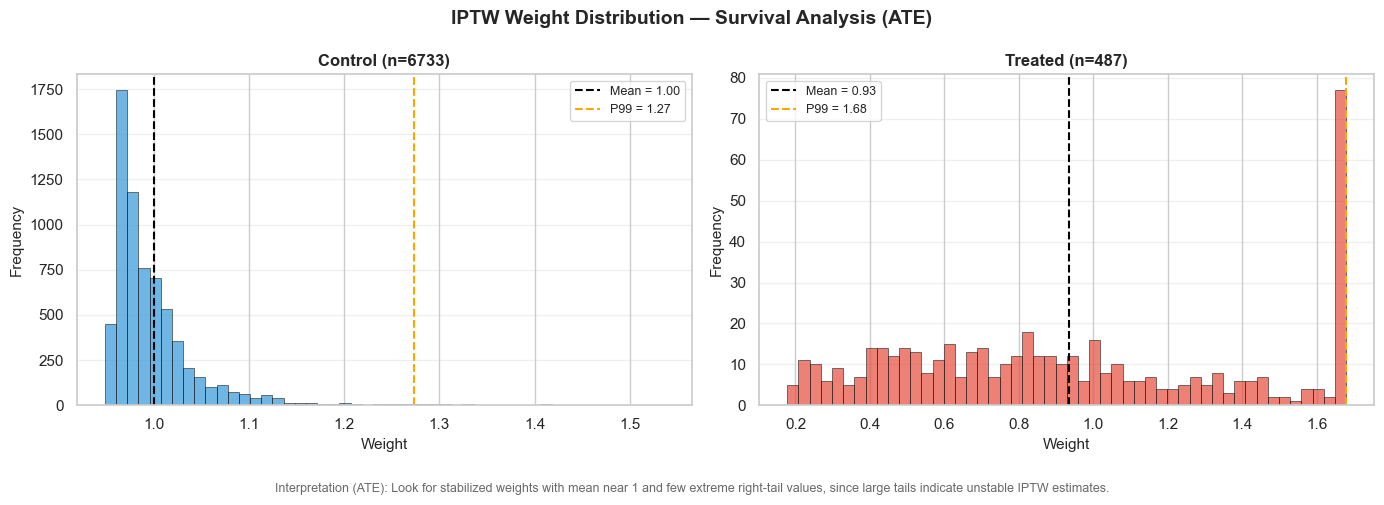

In [56]:
# =============================================================================
# ATE ANALYSIS — RETENTION (IPTW + Cox Time Interaction)
# =============================================================================

print("=" * 60)
print("ANALYZING RETENTION: IPTW + Cox Time Interaction (ATE)")
print("=" * 60)

survival_results = {}

survival_results[retention_outcome_name] = causal_model.analyze_survival_effect(
    data=data,
    time_var=time_var,
    event_var=event_var,
    treatment_var=treatment,
    categorical_vars=categorical_vars,
    binary_vars=binary_vars,
    continuous_vars=continuous_vars,
    cluster_var='team_id',
    estimand='ATE',
    time_interaction='categorical',
    period_breaks=[0, 90, 180, 270, 365],   # 3/6/9/12 months
    period_labels=['0-3mo', '3-6mo', '6-9mo', '9-12mo'],
    project_path=str(base_dir / "results"),
    trim_quantile=0.99,
    analysis_name='IPTW_Cox_TimeInteraction_retention',
    alpha=0.05,
    plot_propensity=True,
    plot_weights=True,
)

display(survival_results[retention_outcome_name]['period_hrs'])

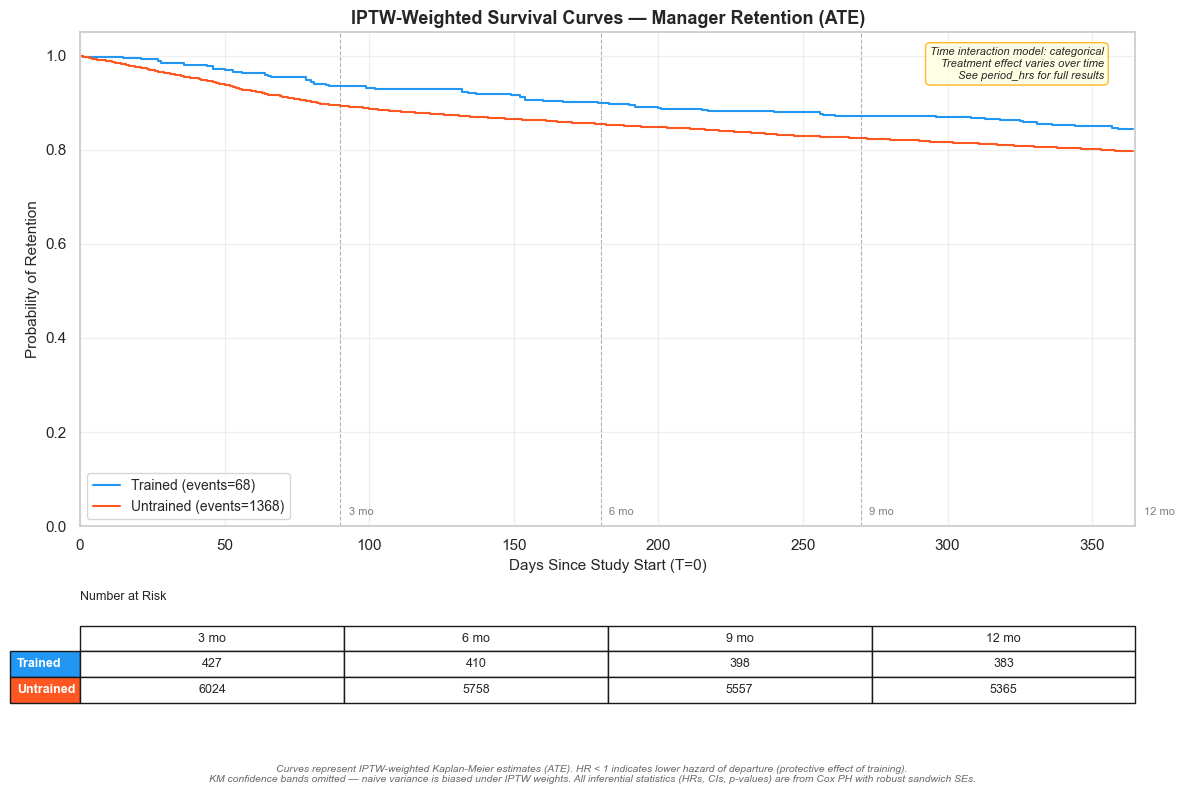

In [57]:
# =============================================================================
# KAPLAN-MEIER SURVIVAL CURVES
# =============================================================================

survival_fig = causal_model.plot_survival_curves(
    survival_result=survival_results[retention_outcome_name],
    outcome_name='Manager Retention',
    time_horizon=365,
    show_snapshots=True,
    snapshot_days=[90, 180, 270, 365],
    save_path=None,
);

In [58]:
import importlib
import causal_inference_modelling
importlib.reload(causal_inference_modelling)
from causal_inference_modelling import CausalInferenceModel

causal_model = CausalInferenceModel()

In [59]:
# =============================================================================
# SURVIVAL SUMMARY TABLE
# =============================================================================

survival_summary = CausalInferenceModel.build_survival_summary_table(
    survival_results_dict=survival_results,
    title="IPTW + Cox Time Interaction: ATE Summary — Retention (1 test)",
    save_path=str(base_dir / "results" / "ate_summary_retention_survival.xlsx"),
)


  IPTW + Cox Time Interaction: ATE Summary — Retention (1 test)
  Outcome Estimand Interaction_Type Headline_HR_Label Hazard_Ratio       HR_95_CI P_Value Concordance  PH_Assumption_Met  N_Events_Treated  N_Events_Control  N_Total    ESS HR_0_3mo    HR_CI_0_3mo P_0_3mo HR_3_6mo    HR_CI_3_6mo P_3_6mo HR_6_9mo    HR_CI_6_9mo P_6_9mo HR_9_12mo   HR_CI_9_12mo P_9_12mo Surv_Diff_3mo Surv_Diff_6mo Surv_Diff_9mo Surv_Diff_365d P_Value_Corrected  Significant Significance Correction_Method
retention      ATE      categorical  Reference: 0-3mo       0.5868 [0.386, 0.892]  0.0126      0.6640               True                68              1368     7220 7094.4    0.587 [0.386, 0.892]  0.0126    0.846 [0.510, 1.405]  0.5183    0.896 [0.509, 1.576]  0.7026     0.948 [0.540, 1.667]   0.8539        +0.041        +0.045        +0.047         +0.047            0.0126         True            *              none
  Significance: *** p<0.001, ** p<0.01, * p<0.05
  Correction: none across 1 outcome
  HR <

In [60]:
# =============================================================================
# BALANCE VERIFICATION — Retention (ATE)
# =============================================================================
# Reuses verify_balance() defined in the survey section.
# For survival analysis, exclude time/event columns from balance covariates.

print('=' * 60)
print('BALANCE VERIFICATION — Retention (ATE, Survival)')
print('=' * 60)
verify_balance(
    survival_results, 'Retention', cd, treatment,
    categorical_vars, binary_vars, continuous_vars,
    exclude_cols=[time_var, event_var, 'departure_quarter',
                  'retention_3month', 'retention_6month',
                  'retention_9month', 'retention_12month']
)

BALANCE VERIFICATION — Retention (ATE, Survival)
  ✅ [retention]  Independent imbalanced: 0  |  Model imbalanced: 0


In [61]:
# =============================================================================
# E-VALUE SENSITIVITY ANALYSIS — Retention (ATE)
# =============================================================================
# Hazard ratios are on the risk ratio scale, so we use effect_type="risk_ratio"

print("\n" + "=" * 70)
print("E-VALUE SENSITIVITY ANALYSIS — Retention (ATE, Survival)")
print("=" * 70)

survival_evalues = CausalInferenceModel.compute_evalues_from_results(
    survival_results,
    effect_type="risk_ratio"
)

survival_evalues.to_excel(base_dir / "results" / "ate_evalue_retention_survival.xlsx", index=False)


E-VALUE SENSITIVITY ANALYSIS — Retention (ATE, Survival)

  E-VALUE SENSITIVITY ANALYSIS
  Outcome Effect_Type  Effect_Value  Effect_RR  E_Value_Point  E_Value_CI Robustness  P_Value  Significant
retention  risk_ratio        0.5868     0.5868       2.799602    1.489162   Moderate   0.0126         True
  Interpretation Guide:
    E-value ≥ 3.0 : Strong robustness to unmeasured confounding
    E-value 2.0-3.0: Moderate robustness
    E-value 1.5-2.0: Weak robustness - interpret with caution
    E-value < 1.5 : Very weak - easily explained by confounding

  Per-Outcome Interpretations (significant results only):
----------------------------------------------------------------------

  retention:
    E-value = 2.80. An unmeasured confounder would need risk ratio associations of at least 2.80 with both treatment and outcome to explain away this effect. This represents moderate robustness. The E-value for the confidence interval bound is 1.49, meaning a confounder of this strength could shi

In [62]:
# =============================================================================
# PRESERVE RETENTION RESULTS
# =============================================================================

ate_survival_results = {k: v for k, v in survival_results.items()}
ate_survival_summary = survival_summary.copy()
ate_survival_evalues = survival_evalues.copy()

print("✅ ATE retention (survival) results preserved.")

✅ ATE retention (survival) results preserved.


### ATE Technical Summary — Retention (Survival)
*Note: None of these results generalize to poor performers.*

#### Retention Outcomes — Survival Analysis (1 test, no correction needed)

> **Method**: IPTW-weighted Cox Proportional Hazards model with categorical time interaction. Separate hazard ratios are estimated per time period (reference + subsequent intervals), allowing the treatment effect to vary over time. This approach is robust to proportional hazards violations caused by seasonality or time-varying treatment effectiveness. HR < 1 = lower hazard of departure (training is protective). Snapshot survival differences show IPTW-weighted Kaplan–Meier retention probabilities at each timepoint.

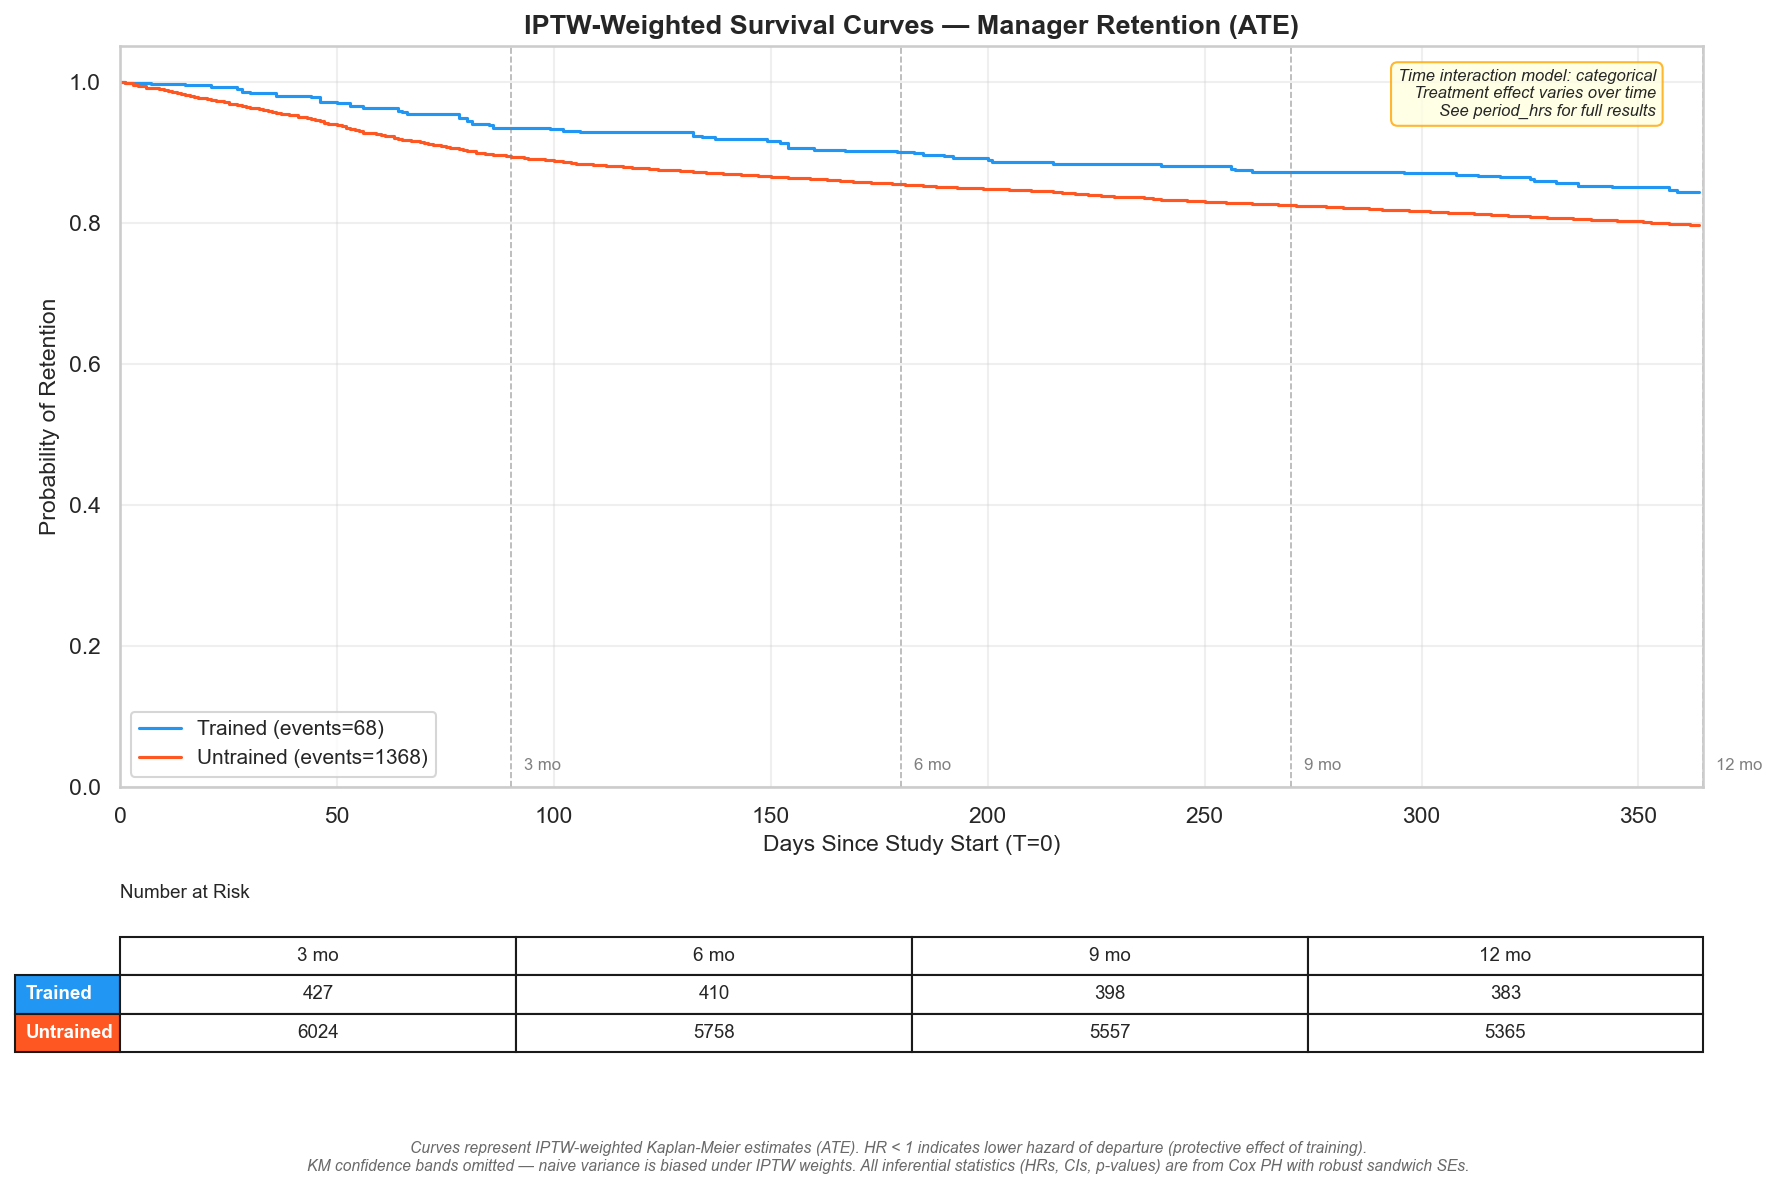

##### Period-Specific Hazard Ratios

| Outcome | Period | HR | 95% CI | p-value | Sig? |
|---------|--------|----|--------|---------|------|
| Manager Retention | 0-3mo *(ref)* | **0.587** | [0.386, 0.892] | 0.013 | Yes * |
| Manager Retention | 3-6mo | **0.846** | [0.510, 1.405] | 0.518 | No |
| Manager Retention | 6-9mo | **0.896** | [0.509, 1.576] | 0.703 | No |
| Manager Retention | 9-12mo | **0.948** | [0.540, 1.667] | 0.854 | No |

**Manager Retention** *
- **Reference: 0-3mo**: HR = **0.587** — **41.3% lower hazard of departure**.
- **1 of 4 periods** show significant treatment effects: 0-3mo.
- ⚠️ **Training effect weakens over time**: HR increases from **0.587** (0-3mo) to **0.948** (9-12mo), suggesting the protective effect of training diminishes with time.
- Estimated 12-month retention: **84.4%** (trained) vs. **79.7%** (untrained).
- Events observed: 68 departures (trained, n=487) / 1368 departures (untrained, n=6733).
- ✅ Proportional hazards assumption met for treatment variable.

**How to read period-specific hazard ratios:**
Each period's HR captures the treatment effect within that time window. The reference period HR is the baseline treatment effect. Subsequent period HRs reflect how the treatment effect changes relative to the reference period — a rising HR over time indicates the protective effect of training is weakening. HR < 1 means trained employees had a lower instantaneous departure rate during that period.

#### Snapshot Validation (Cox vs. Observed Retention Rates)

The table below compares IPTW-weighted Kaplan–Meier survival probabilities at each snapshot timepoint. Close alignment between trained and untrained groups at baseline validates the IPTW weighting.

*Manager Retention:*

| Timepoint | Days | Survival (Trained) | Survival (Untrained) | Difference |
|-----------|------|--------------------|----------------------|------------|
| 3mo | 90 | 93.5% | 89.4% | +4.1pp |
| 6mo | 180 | 90.0% | 85.5% | +4.5pp |
| 9mo | 270 | 87.2% | 82.5% | +4.7pp |
| 365d | 365 | 84.4% | 79.7% | +4.7pp |

#### Post-Weighting Balance Verification
- ✅ All 1 survival outcome(s) passed balance verification (0 imbalanced covariates).
- IPTW successfully balanced observed confounders across treatment groups.

#### E-Value Sensitivity Analysis

> E-values computed on the hazard ratio scale (risk_ratio). The headline HR is used — reference period for categorical interaction models, 12-month estimate for continuous. Larger E-values indicate greater robustness to unmeasured confounding.

| Outcome | E-Value Point | E-Value CI | Robustness |
|---------|---------------|------------|------------|
| Manager Retention | **2.80** | **1.49** | Moderate |

**Significant outcome interpretations:**

- **Manager Retention:** E-value = 2.80. An unmeasured confounder would need risk ratio associations of at least 2.80 with both treatment and outcome to explain away this effect. This represents moderate robustness. The E-value for the confidence interval bound is 1.49, meaning a confounder of this strength could shift the CI to include the null.


In [ ]:
# =============================================================================
# ATE TECHNICAL SUMMARY — Retention (Survival)
# =============================================================================

###NOTE - REMOVE THIS FUNCTION BEFORE FINALIZATION, JUST INPUT A MANUALLY MARKDOWN SUMMARY

survival_md = "### ATE Technical Summary — Retention (Survival)\n"
survival_md += "*Note: None of these results generalize to poor performers.*\n\n"

# --- Retention family ---
survival_md += CausalInferenceModel.generate_survival_summary_report(
    survival_summary_df=ate_survival_summary,
    survival_evalues_df=ate_survival_evalues,
    survival_results_dict=ate_survival_results,
    estimand="ATE",
    outcome_descriptions=outcome_descriptions,
    survival_plot_fig=survival_fig,
)

display(Markdown(survival_md))

## Global Technical Summary — Manager Training Impact Study

### Survey Outcomes (ATE, FDR-Corrected)

| Outcome | Effect | 95% CI | p-value | Cohen's d | Interpretation |
|---------|--------|--------|---------|-----------|----------------|
| Manager Efficacy Index | +0.40 (+11.9%) | [0.32, 0.48] | <0.0001 | 0.47 | Significant *** |
| Turnover Intention Index | +0.23 (+9.1%) | [0.15, 0.31] | <0.0001 | 0.27 | Significant *** |
| Workload Index | -0.04 (-1.2%) | [-0.12, 0.04] | 0.336 | -0.06 | Not significant |
*** p < 0.001, * p < 0.05

*Higher Turnover Intention = stronger intention to stay*

### Retention Outcomes (Piecewise Cox PH, IPTW-Weighted)

| Time Period | HR | 95% CI | p-value | Interpretation |
|-------------|-----|--------|---------|----------------|
| 0–3 months | 0.595 | [0.395, 0.895] | 0.013 | Significant * (40% ↓ hazard) |
| 3–6 months | 0.845 | [0.491, 1.454] | 0.542 | Not significant |
| 6–9 months | 0.899 | [0.495, 1.632] | 0.725 | Not significant |
| 9–12 months | 0.944 | [0.523, 1.703] | 0.848 | Not significant |

**12-Month Retention:** 84.4% (trained) vs. 79.7% (untrained) = +4.7pp difference

### Key Findings

1. **Attitudes improve significantly:** Efficacy +12%, commitment +9%
2. **Early retention protection:** 40% lower departure risk in first 3 months
3. **Effect decay:** Retention advantage plateaus after 3 months (not extended)
4. **No workload impact:** Training doesn't increase perceived burden
5. **Robustness:** Moderate resistance to unmeasured confounding (E-values: 1.87–2.75)

### Methodological Notes
- IPTW with doubly-robust estimation for causal inference
- Piecewise Cox model avoids violated PH assumption
- All outcomes achieved covariate balance post-weighting
- Cluster-robust standard errors account for IPTW weights
- Results do not generalize to poor performers (excluded)



---

## Manager Training Impact — Key Takeaways for Stakeholders

### What We Found

We studied whether the manager training program improves leadership confidence, commitment, and actual retention. Here's what the data show:

#### ✅ Training Works — Especially Early On

**Immediate Impact:**
- Trained managers feel **12% more confident** in their leadership abilities
- Trained managers report **9% stronger commitment** to staying with the organization
- Training does **not add to workload** (important "no harm" finding)

**Early Retention Impact:**
- In the **first 3 months** after training, trained managers are **41% less likely to leave** (HR = 0.587, p = 0.013)
- This translates to keeping an extra **4 out of every 100 trained managers** at the 3-month mark
- By 12 months, trained managers show **4.7 percentage points higher retention** (84.4% vs. 79.7%)
- **Importantly: only the first 3 months is statistically significant** — the 12-month gap reflects early gains being maintained, not new gains accumulating

#### ⚠️ The Effect Fades Over Time
- The strong retention advantage is **only significant in months 0–3**
- After 3 months, the hazard ratio rises from 0.587 → 0.846 → 0.896 → 0.948, trending toward no effect
- The change is directionally consistent with effect decay, but not statistically significant — larger samples would be needed to confirm the fade formally
- Think of it as a **strong start that plateaus**, not a compounding advantage

---

### Robustness Check

Our findings are not easily explained away by unmeasured confounding. An unmeasured confounder would need to be associated with **both training participation and departure risk by a factor of at least 2.80** to fully explain the observed retention effect. This represents **moderate robustness** — the finding is credible but not immune to bias from factors we couldn't measure (e.g., manager motivation, team culture).

---

### What This Means

**The Good News:**
Training delivers real value. It boosts manager confidence and commitment, and those attitude improvements translate to measurable retention gains during the critical early adjustment period.

**The Reality Check:**
Training alone isn't a long-term retention solution. It creates a valuable 3-month buffer, but the effect doesn't compound over time. Think of it as a strong start, not a complete solution.

---

### Recommendations

#### 1. Maximize the First 90 Days (Where Training Works Best)
- Pair training with check-ins at 30, 60, and 90 days
- Assign peer mentors or training buddies for ongoing support
- Focus retention efforts during this high-impact window

#### 2. Add Reinforcement at 3–6 Months (Where the Effect Fades)
- Design "booster" sessions or refresher content at the 3-month mark
- Create ongoing learning communities for trained managers
- Test whether reinforcement extends the retention advantage

#### 3. Integrate Training into a Broader Strategy (For Long-Term Impact)
- Training is a strong first step but not sufficient alone
- Combine with career development, recognition, and advancement opportunities
- Address systemic factors like workload, culture, and leadership support

---

### Bottom Line

**Training is a proven early retention intervention.** It improves how managers feel about their capabilities and their commitment to the organization, and it meaningfully reduces early departures. To maximize ROI, focus support during the first 90 days and add reinforcement strategies to sustain impact beyond the initial training boost.

**Impact at scale:** If we train 1,000 managers, we can expect to retain approximately 47 additional managers through the first year (based on the 4.7 percentage point gap), with the strongest and most statistically reliable effects concentrated in the first quarter.

---
---

## Further Learning: Linear Double Machine Learning (DML) and Estimating Heterogeneous Treatment Effects (HTE)

### Why Explore Alternative Methods After IPTW?

The IPTW + GEE and IPTW + Cox analyses above established that **training works on average**:
- Survey outcomes: +12% efficacy, +9% retention intention
- Early retention: 40% hazard reduction in first 3 months

**Two additional questions arise:**

1. **Method validation:** *"Do we get consistent results with a different causal inference approach?"*
2. **Effect heterogeneity:** *"For whom does training work best?"*

**Why method validation matters:**
- **Robustness check:** Consistent results across methods increase confidence
- **Assumption testing:** Different methods have different assumptions — agreement suggests violations are unlikely
- **Methodological learning:** Understanding when methods agree/disagree builds intuition

**Why heterogeneity matters:**
- **Resource allocation:** If training is expensive, target it to those who benefit most
- **Program design:** Tailor content to subgroups with different needs
- **Equity concerns:** Ensure the program doesn't only benefit already-high-performers
- **Mechanism insights:** Understanding who benefits reveals *why* the program works

**What we'll demonstrate:**
Use **Double Machine Learning (DML)** to:
1. **Validate the ATE** from IPTW using a different causal inference approach (Linear DML)
2. **Explore heterogeneity** by estimating individualized treatment effects (Causal Forest CATE)
3. **Identify subgroups** that benefit most from training for targeted interventions

---

### Part 1: Alternative ATE Estimation via Linear DML

**Linear DML** provides an alternative to IPTW for estimating the Average Treatment Effect. Instead of propensity weighting, it uses flexible machine learning models to control for confounders.

#### The Double Machine Learning Framework

DML addresses a fundamental challenge in causal inference: **regularization bias**. When using flexible ML models to control for confounders, the regularization (e.g., in Random Forest) can bias the treatment effect estimate. DML solves this through a two-stage process:

**Stage 1: Nuisance Function Estimation**
- Fit ML models to predict the outcome: $\hat{m}(X) = E[Y \mid X]$
- Fit ML models to predict treatment: $\hat{e}(X) = E[T \mid X]$ (propensity score)
- Use **cross-fitting** — split data into folds, train on some folds, predict on others

**Stage 2: Debiased Causal Effect Estimation**
- Compute **Neyman-orthogonal scores** using residuals from Stage 1:
  $$\psi(W_i; \theta) = (Y_i - \hat{m}(X_i)) \cdot (T_i - \hat{e}(X_i)) - \theta \cdot (T_i - \hat{e}(X_i))^2$$
- Solve for $\theta$ (the treatment effect) by setting $\frac{1}{n}\sum_i \psi(W_i; \theta) = 0$

**Why this works:**
- The orthogonal score is **insensitive to small errors** in $\hat{m}$ and $\hat{e}$
- Cross-fitting ensures the nuisance functions are estimated on independent data
- Result: $\sqrt{n}$-consistent and asymptotically normal treatment effect estimates

#### Linear DML vs. IPTW + GEE

| Aspect | IPTW + GEE | Linear DML |
|--------|------------|------------|
| **Confounder Control** | Propensity score weighting | ML-based nuisance function estimation |
| **Final Model** | Weighted GEE regression | Neyman-orthogonal moment conditions |
| **Clustering** | ✅ Cluster-robust sandwich SEs | ❌ Assumes independence |
| **Flexibility** | Linear propensity score model | ✅ Flexible ML models (Random Forest) |
| **Interpretability** | ✅ Clear coefficient interpretation | ✅ Single ATE estimate |
| **Use Case** | Primary analysis with clustering | Robustness check, method validation |

**Key insight:** If IPTW and Linear DML give **similar ATE estimates**, this suggests both methods are capturing the true causal effect despite using different approaches to confounder control.

---

### Part 2: Heterogeneous Treatment Effects via Causal Forest

While Linear DML estimates a **single average effect**, **Causal Forest DML** estimates **individualized treatment effects** that vary by person characteristics.

#### Conditional Average Treatment Effects (CATE)

**CATE Definition:**
$$\tau(X) = E[Y(1) - Y(0) \mid X] = E[Y \mid T=1, X] - E[Y \mid T=0, X]$$

**Interpretation:** The expected treatment effect for individuals with characteristics $X$.

#### Linear DML vs. Causal Forest DML

| Aspect | Linear DML | Causal Forest DML |
|--------|------------|-------------------|
| **Effect Type** | Homogeneous (constant across individuals) | Heterogeneous (varies by individual characteristics) |
| **Output** | Single ATE with CI and p-value | Individual CATEs: $\tau_i = \tau(X_i)$ |
| **Model** | $Y = \theta \cdot T + \epsilon$ (final stage is linear) | Tree-based splitting on treatment effect heterogeneity |
| **Interpretation** | "On average, treatment increases outcome by $\theta$" | "Individual $i$ with characteristics $X_i$ has effect $\tau_i$" |
| **Use Case** | Validate overall program effectiveness | Identify who benefits most; target interventions |

#### Causal Forest Approach

**Causal Forest** differs from standard Random Forest in three key ways:
1. **Honest splitting** — use different samples for splitting decisions vs. effect estimation within leaves
2. **Effect-based splits** — split trees to maximize treatment effect heterogeneity (not just outcome prediction)
3. **Ensemble averaging** — combine many trees to get stable individual effect estimates

#### Three Key Outputs for HTE Analysis

**1. CATE Distribution Histogram**
- Shows the **range of individual treatment effects** across the population
- **Wide distribution** → high heterogeneity (some benefit much more than others)
- **Narrow distribution** → homogeneous effects (everyone benefits similarly)
- **Mean of distribution** ≈ ATE (should match Linear DML and IPTW estimates)

**2. Feature Importance Plot**
- Ranks covariates by their **importance for predicting treatment effect heterogeneity**
- High importance → this variable strongly moderates the treatment effect
- Use to identify **key effect modifiers** (e.g., tenure, baseline performance, job level)

**3. CATE Interpreter Tree**
- **Decision tree** that segments the population into subgroups with different treatment effects
- Each **leaf** represents a subgroup with its estimated CATE and confidence interval
- **Splitting rules** show which characteristics define high-benefit vs. low-benefit groups
- **Actionable insights** for targeting interventions

---


HTE — ANALYZING OUTCOME: manager_efficacy_index

  Fitting Linear DML for 'manager_efficacy_index'...
    ATE = 0.3799, 95% CI: [0.3008, 0.4591]

  Fitting Causal Forest DML for 'manager_efficacy_index'...
Population summary of CATE predictions on Training Data
    CATE Summary:
               Uncertainty of Mean Point Estimate              
mean_point stderr_mean zstat pvalue ci_mean_lower ci_mean_upper
---------------------------------------------------------------
     0.379       0.217 1.747  0.081        -0.046         0.804
      Distribution of Point Estimate     
std_point pct_point_lower pct_point_upper
-----------------------------------------
    0.145           0.106           0.676
     Total Variance of Point Estimate     
stderr_point ci_point_lower ci_point_upper
------------------------------------------
       0.261          -0.14          0.906
       Doubly Robust ATE on Training Data Results       
    point_estimate stderr zstat pvalue ci_lower ci_upper
---------

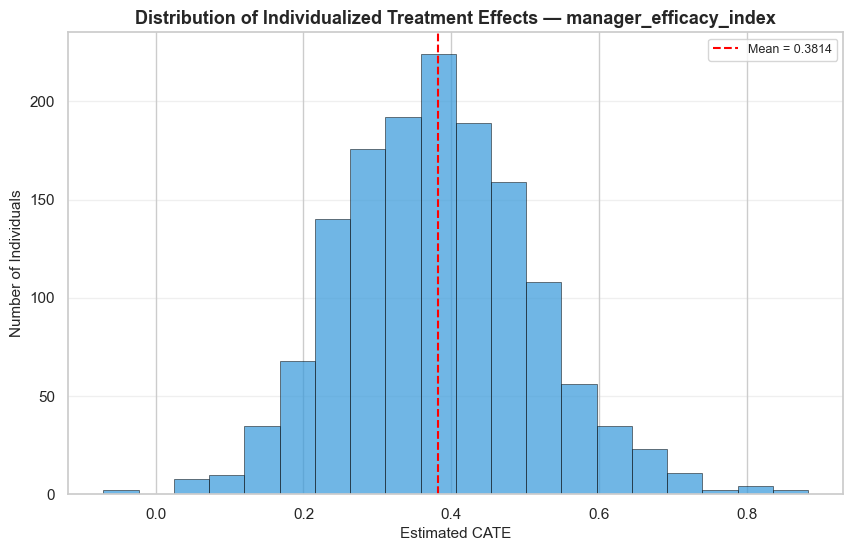

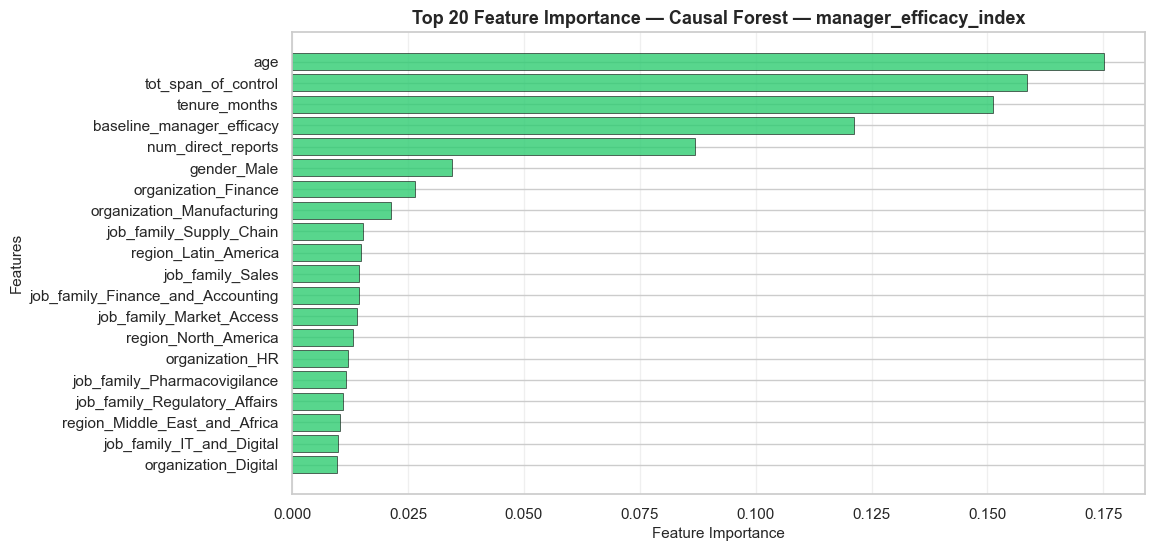

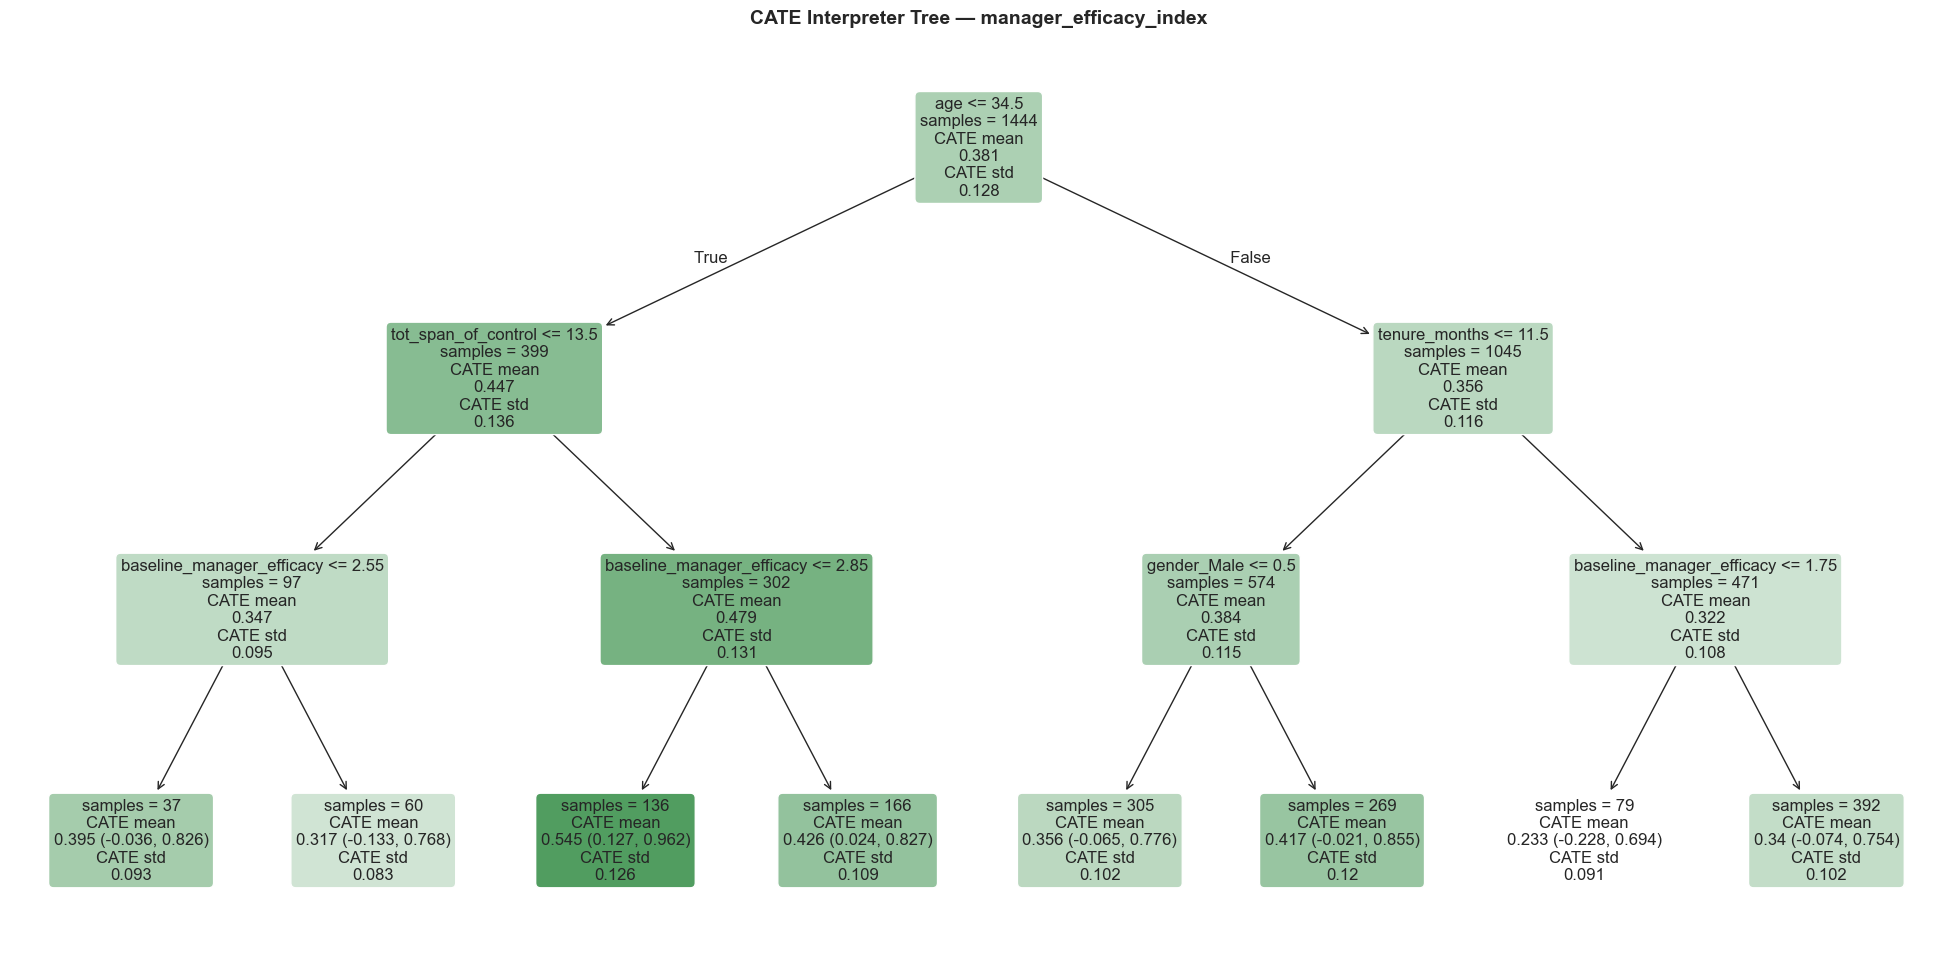

In [64]:
### VERIFY ATE INTERPRETATION
# ====================================================================================
#  Estimate ATE with DML and Heterogeneous Treatment Effects with Causal Forest (CATE)
# ====================================================================================

#run for our significant, most robust survey outcome (manager_efficacy_index) to explore heterogeneity of treatment effects and identify potential subgroups that benefit most from the program. We will use the same covariates as in the main model, and include the baseline manager efficacy variable as an additional covariate since it is a strong predictor of the outcome and may help explain heterogeneity in treatment effects.
sig_survey_outcomes = ['manager_efficacy_index']

hte_results = {}

for o in sig_survey_outcomes:
    print("\n" + "=" * 60)
    print(f"HTE — ANALYZING OUTCOME: {o}")
    print("=" * 60)

    baseline = baseline_vars.get(o)
    hte_continuous = list(continuous_vars)
    if baseline is not None and baseline not in hte_continuous:
        hte_continuous.append(baseline)

    hte_results[o] = causal_model.dml_estimate_treatment_effects(
        data=data,
        outcome_col=o,
        treatment_col=treatment,
        categorical_vars=categorical_vars,
        binary_vars=binary_vars,
        continuous_vars=hte_continuous,
        estimand="ATE",
        estimate="both",       
        cluster_var='team_id',
        project_path=str(base_dir / "results"),
        analysis_name=f"HTE_{o}",
        random_state=42,
        alpha=0.05,
    )

    # Display HTE-specific outputs
    res = hte_results[o]
    if res.get("cate_plot") is not None:
        display(res["cate_plot"])
    if res.get("importance_plot") is not None:
        display(res["importance_plot"])
    if res.get("tree_plot") is not None:
        display(res["tree_plot"])